In [12]:
# ============================================================
# BLOQUE 1: Imports y configuración general
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sqlalchemy import create_engine, text

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

%matplotlib inline

# ------------------------------------------------------------
# Ruta de la base SQLite
# ------------------------------------------------------------

DB_PATH = "/home/cdo/Downloads/CEV_db/cev_compiled.sqlite"

# ------------------------------------------------------------
# Carpeta de salida
# ------------------------------------------------------------

OUTPUT_DIR = Path("/home/cdo/Downloads/CEV_db/outputs_analisis_cev_jupyter")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Parámetros globales
# ------------------------------------------------------------

DPI = 180
SAVE_FIGURES = True
SHOW_FIGURES = True

RANDOM_STATE = 42

print("Configuración cargada.")
print(f"DB_PATH: {DB_PATH}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

Configuración cargada.
DB_PATH: /home/cdo/Downloads/CEV_db/cev_compiled.sqlite
OUTPUT_DIR: /home/cdo/Downloads/CEV_db/outputs_analisis_cev_jupyter


In [13]:
# ============================================================
# BLOQUE 2: Conexión SQLite
# ============================================================

if not os.path.exists(DB_PATH):
    raise FileNotFoundError(f"No existe la base de datos: {DB_PATH}")

engine = create_engine(f"sqlite:///{DB_PATH}")

with engine.connect() as conn:
    test = conn.execute(text("SELECT sqlite_version();")).fetchone()

print("Conexión creada correctamente.")
print(f"SQLite version: {test[0]}")

Conexión creada correctamente.
SQLite version: 3.53.1


In [14]:
# ============================================================
# BLOQUE 3: Inspección de estructura de la base
# ============================================================

def list_tables(engine):
    sql = """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name;
    """
    with engine.connect() as conn:
        return pd.read_sql_query(text(sql), conn)


def table_info(engine, table_name):
    with engine.connect() as conn:
        return pd.read_sql_query(text(f'PRAGMA table_info("{table_name}");'), conn)


tables = list_tables(engine)
display(tables)

for table in [
    "descripcion_general",
    "descripcion_equipos",
    "requerimientos",
]:
    print(f"\n--- {table} ---")
    display(table_info(engine, table))

,name
0,descripcion_equipos
1,descripcion_general
2,elementos_opacos
3,elementos_traslucidos
4,exigencia_u_normativa
5,materialidades
6,puentes_termicos
7,requerimientos
8,requerimientos_total



--- descripcion_general ---


,cid,name,type,notnull,dflt_value,pk
0,0,document_id,TEXT,0,None,1
1,1,source_pdf,TEXT,0,None,0
2,2,estado_cev,TEXT,0,None,0
3,3,region,TEXT,0,None,0
4,4,comuna,TEXT,0,None,0
5,5,direccion,TEXT,0,None,0
6,6,rol_vivienda,TEXT,0,None,0
7,7,tipo_vivienda,TEXT,0,None,0
8,8,superficie_util,REAL,0,None,0
9,9,ahorro,REAL,0,None,0



--- descripcion_equipos ---


,cid,name,type,notnull,dflt_value,pk
0,0,document_id,TEXT,0,None,1
1,1,calef_proyec_descripcion,TEXT,0,None,0
2,2,ilum_proyec_descripcion,TEXT,0,None,0
3,3,acs_proyec_descripcion,TEXT,0,None,0
4,4,ernc_proyec_descripcion,TEXT,0,None,0
5,5,calef_proyec_kwh,REAL,0,None,0
6,6,ilum_proyec_kwh,REAL,0,None,0
7,7,acs_proyec_kwh,REAL,0,None,0
8,8,ernc_proyec_kwh,REAL,0,None,0
9,9,calef_ref_descripcion,TEXT,0,None,0



--- requerimientos ---


,cid,name,type,notnull,dflt_value,pk
0,0,document_id,TEXT,0,None,1
1,1,acs_kwhm2,REAL,0,None,0
2,2,ilum_kwhm2,REAL,0,None,0
3,3,calef_kwhm2,REAL,0,None,0
4,4,ernc_kwhm2,REAL,0,None,0
5,5,consumo_kwhm2,REAL,0,None,0
6,6,emisiones_co2,REAL,0,None,0


In [15]:
# ============================================================
# BLOQUE 4: Consulta base unificada
# ============================================================

BASE_SQL = """
SELECT
    dg.document_id,

    dg.source_pdf,
    dg.estado_cev,
    dg.region,
    dg.comuna,
    dg.direccion,
    dg.rol_vivienda,

    dg.tipo_inmueble,
    dg.superficie_util,
    dg.ahorro,
    dg.etiqueta,
    dg.demanda_calef,
    dg.demanda_refri,
    dg.fecha_emision,
    dg.zona_termica,

    de.calef_proyec_kwh,
    de.acs_proyec_kwh,

    r.acs_kwhm2,
    r.calef_kwhm2,
    r.consumo_kwhm2,
    r.emisiones_co2

FROM descripcion_general dg
LEFT JOIN descripcion_equipos de
    ON dg.document_id = de.document_id
LEFT JOIN requerimientos r
    ON dg.document_id = r.document_id
"""

NUMERIC_COLUMNS = [
    "superficie_util",
    "ahorro",
    "demanda_calef",
    "demanda_refri",
    "calef_proyec_kwh",
    "acs_proyec_kwh",
    "acs_kwhm2",
    "calef_kwhm2",
    "consumo_kwhm2",
    "emisiones_co2",
]

CATEGORICAL_COLUMNS = [
    "estado_cev",
    "region",
    "comuna",
    "tipo_inmueble",
    "etiqueta",
    "zona_termica",
]

MAIN_COLUMNS = [
    "calef_proyec_kwh",
    "acs_proyec_kwh",
    "tipo_inmueble",
    "superficie_util",
    "etiqueta",
    "demanda_calef",
    "demanda_refri",
    "zona_termica",
    "acs_kwhm2",
    "calef_kwhm2",
    "consumo_kwhm2",
]


def load_base_dataframe(sample_n=None):
    sql = BASE_SQL

    if sample_n is not None:
        sql += f"\nORDER BY RANDOM()\nLIMIT {int(sample_n)}"

    with engine.connect() as conn:
        df = pd.read_sql_query(text(sql), conn)

    for col in NUMERIC_COLUMNS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    for col in CATEGORICAL_COLUMNS:
        if col in df.columns:
            df[col] = df[col].astype("string").str.strip()

    return df


df = load_base_dataframe()

print(f"Registros cargados: {len(df):,}")
display(df.head())

Registros cargados: 228,973


,document_id,source_pdf,estado_cev,region,comuna,direccion,rol_vivienda,tipo_inmueble,superficie_util,ahorro,...,demanda_calef,demanda_refri,fecha_emision,zona_termica,calef_proyec_kwh,acs_proyec_kwh,acs_kwhm2,calef_kwhm2,consumo_kwhm2,emisiones_co2
0,f8315b2026,ficha_algarrobo_vista_mar_330753-departamento_...,precalificada,Región de Valparaíso,Algarrobo,Avenida Costanera 29,331-222,depto,78.4,79.0,...,3.9,11.8,09-04-2026,C,597.8,3706.5,47.3,7.6,58.9,13.7
1,4d97c72026,ficha_algarrobo_vista_mar_330754-departamento_...,precalificada,Región de Valparaíso,Algarrobo,Avenida Costanera 29,331-222,depto,82.5,72.0,...,4.3,22.4,09-04-2026,C,690.8,3833.7,46.5,8.4,58.7,13.7
2,12d3512026,ficha_algarrobo_vista_mar_330755-departamento_...,precalificada,Región de Valparaíso,Algarrobo,Avenida Costanera 29,331-222,depto,82.5,51.0,...,0.0,41.4,09-04-2026,C,6.6,3833.7,46.5,0.1,50.5,11.8
3,99374b2026,ficha_algarrobo_vista_mar_330756-departamento_...,precalificada,Región de Valparaíso,Algarrobo,Avenida Costanera 29,331-222,depto,78.4,60.0,...,0.2,30.5,09-04-2026,C,29.1,3706.5,47.3,0.4,51.7,12.1
4,c5ff1f2026,ficha_algarrobo_vista_mar_330757-departamento_...,precalificada,Región de Valparaíso,Algarrobo,Avenida Costanera 29,331-222,depto,55.2,63.0,...,0.2,26.4,09-04-2026,C,26.7,2887.8,52.3,0.5,56.8,13.3


In [16]:
# ============================================================
# BLOQUE 5: Diagnóstico inicial
# ============================================================

display(Markdown("## Resumen general"))

print(f"Número de filas: {len(df):,}")
print(f"Número de documentos únicos: {df['document_id'].nunique():,}")

display(Markdown("### Valores no nulos por columna principal"))

non_null_summary = (
    df[["document_id"] + MAIN_COLUMNS]
    .notna()
    .sum()
    .rename("n_no_nulos")
    .to_frame()
)

non_null_summary["pct_no_nulos"] = 100 * non_null_summary["n_no_nulos"] / len(df)

display(non_null_summary)

display(Markdown("### Resumen numérico"))

display(
    df[NUMERIC_COLUMNS]
    .describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99])
    .T
)

display(Markdown("### Frecuencias categóricas principales"))

for col in ["tipo_inmueble", "etiqueta", "zona_termica", "region", "estado_cev"]:
    if col in df.columns:
        display(Markdown(f"#### {col}"))
        display(df[col].value_counts(dropna=False).head(30).to_frame("n"))

## Resumen general

Número de filas: 228,973
Número de documentos únicos: 228,973


### Valores no nulos por columna principal

,n_no_nulos,pct_no_nulos
document_id,228973,100.000000
calef_proyec_kwh,228973,100.000000
acs_proyec_kwh,228884,99.961131
tipo_inmueble,228603,99.838409
superficie_util,228973,100.000000
etiqueta,228973,100.000000
demanda_calef,228973,100.000000
demanda_refri,228973,100.000000
zona_termica,228973,100.000000
acs_kwhm2,228973,100.000000


### Resumen numérico

...

,n
zona_termica,
D,139441
F,25139
E,17637
C,14090
G,12534
A,12053
B,5101
I,2628
H,349


#### region

,n
region,
Región Metropolitana de Santiago,98441
Región del Maule,22268
Región del Biobío,20916
Región de Valparaíso,12074
Región de la Araucanía,11248
Región de Coquimbo,10113
Región del Libertador Gral. Bernardo O'Higgins,9504
Región de Los Lagos,8916
Región de Ñuble,7179


#### estado_cev

,n
estado_cev,
calificada,117012
precalificada,111960
<NA>,1


In [17]:
# ============================================================
# BLOQUE 8: Función de gráfico por bins
# ============================================================

def plot_binned_numeric_jupyter_sqlite(
    column,
    target_column,
    color_column=None,
    tipo_inmueble=None,
    data=None,
    n_bins=30,
    bin_strategy="quantile",   # "quantile" o "linear"
    y_log=False,
    max_categories=8,
    remove_outliers=False,
    outlier_quantiles=(0.01, 0.99),
    outlier_columns="x",       # "x", "y" o "both"
    save_figures=SAVE_FIGURES,
    show_figures=SHOW_FIGURES,
):
    """
    Grafica target_column vs column usando bins.

    Interpretación:
    Cada punto representa la mediana de target_column dentro de un rango de column.
    Si se usa color_column, se calcula una curva independiente por categoría.
    """

    if data is None:
        data = load_base_dataframe()

    if bin_strategy not in ["quantile", "linear"]:
        raise ValueError("bin_strategy debe ser 'quantile' o 'linear'.")

    if outlier_columns not in ["x", "y", "both"]:
        raise ValueError("outlier_columns debe ser 'x', 'y' o 'both'.")

    if column not in data.columns:
        raise ValueError(f"No existe column={column}")

    if target_column not in data.columns:
        raise ValueError(f"No existe target_column={target_column}")

    cols_required = [column, target_column]

    if color_column is not None:
        if color_column not in data.columns:
            raise ValueError(f"No existe color_column={color_column}")
        cols_required.append(color_column)

    plot_df = data.dropna(subset=cols_required).copy()

    if tipo_inmueble is not None:
        plot_df = plot_df[
            plot_df["tipo_inmueble"].astype(str).str.upper()
            == str(tipo_inmueble).upper()
        ].copy()

    plot_df["x_value"] = pd.to_numeric(plot_df[column], errors="coerce")
    plot_df["y_value"] = pd.to_numeric(plot_df[target_column], errors="coerce")

    plot_df = plot_df.dropna(subset=["x_value", "y_value"]).copy()

    if plot_df.empty:
        print("No hay datos válidos para graficar.")
        return None

    n_before_outliers = len(plot_df)

    x_low = x_high = y_low = y_high = None

    if remove_outliers:
        q_low, q_high = outlier_quantiles

        if outlier_columns in ["x", "both"]:
            x_low = plot_df["x_value"].quantile(q_low)
            x_high = plot_df["x_value"].quantile(q_high)

            plot_df = plot_df[
                plot_df["x_value"].between(x_low, x_high, inclusive="both")
            ].copy()

        if outlier_columns in ["y", "both"]:
            y_low = plot_df["y_value"].quantile(q_low)
            y_high = plot_df["y_value"].quantile(q_high)

            plot_df = plot_df[
                plot_df["y_value"].between(y_low, y_high, inclusive="both")
            ].copy()

    n_after_outliers = len(plot_df)
    n_removed_outliers = n_before_outliers - n_after_outliers

    if plot_df.empty:
        print("No quedan datos después de eliminar outliers.")
        return None

    if y_log:
        plot_df = plot_df[plot_df["y_value"] >= 0].copy()
        plot_df["y_plot"] = np.log1p(plot_df["y_value"])
        y_label = f"log1p({target_column})"
    else:
        plot_df["y_plot"] = plot_df["y_value"]
        y_label = target_column

    if plot_df.empty:
        print("No quedan datos después de aplicar y_log.")
        return None

    if bin_strategy == "quantile":
        plot_df["x_bin"] = pd.qcut(
            plot_df["x_value"],
            q=n_bins,
            duplicates="drop",
        )
    else:
        plot_df["x_bin"] = pd.cut(
            plot_df["x_value"],
            bins=n_bins,
        )

    plot_df = plot_df.dropna(subset=["x_bin"]).copy()

    if plot_df.empty:
        print("No quedan datos después de crear bins.")
        return None

    plot_df["x_bin_mid"] = [
        interval.mid if pd.notna(interval) else np.nan
        for interval in plot_df["x_bin"]
    ]

    plot_df["x_bin_mid"] = pd.to_numeric(plot_df["x_bin_mid"], errors="coerce")

    # ------------------------------------------------------------
    # Caso sin variable de color
    # ------------------------------------------------------------
    if color_column is None:
        grouped = (
            plot_df.groupby("x_bin", observed=True)
            .agg(
                x_mid=("x_bin_mid", "first"),
                y_median=("y_plot", "median"),
                y_mean=("y_plot", "mean"),
                y_p10=("y_plot", lambda s: s.quantile(0.10)),
                y_p90=("y_plot", lambda s: s.quantile(0.90)),
                n=("y_plot", "size"),
                x_min=("x_value", "min"),
                x_max=("x_value", "max"),
                y_min_original=("y_value", "min"),
                y_max_original=("y_value", "max"),
            )
            .reset_index()
            .sort_values("x_mid")
        )

        fig, ax = plt.subplots(figsize=(10, 6))

        ax.plot(
            grouped["x_mid"],
            grouped["y_median"],
            marker="o",
            linewidth=1.5,
            label="Mediana",
        )

        ax.fill_between(
            grouped["x_mid"].astype(float),
            grouped["y_p10"].astype(float),
            grouped["y_p90"].astype(float),
            alpha=0.25,
            label="Percentil 10–90",
        )

        ax.legend()

    # ------------------------------------------------------------
    # Caso con variable de color
    # ------------------------------------------------------------
    else:
        plot_df[color_column] = plot_df[color_column].astype("string").str.strip()

        top_categories = (
            plot_df[color_column]
            .value_counts()
            .head(max_categories)
            .index
        )

        plot_df = plot_df[plot_df[color_column].isin(top_categories)].copy()

        if plot_df.empty:
            print("No quedan datos después de filtrar categorías.")
            return None

        grouped = (
            plot_df.groupby(["x_bin", color_column], observed=True)
            .agg(
                x_mid=("x_bin_mid", "first"),
                y_median=("y_plot", "median"),
                y_mean=("y_plot", "mean"),
                y_p10=("y_plot", lambda s: s.quantile(0.10)),
                y_p90=("y_plot", lambda s: s.quantile(0.90)),
                n=("y_plot", "size"),
                x_min=("x_value", "min"),
                x_max=("x_value", "max"),
                y_min_original=("y_value", "min"),
                y_max_original=("y_value", "max"),
            )
            .reset_index()
            .sort_values(["x_mid", color_column])
        )

        fig, ax = plt.subplots(figsize=(11, 7))

        for category, sub in grouped.groupby(color_column):
            sub = sub.sort_values("x_mid")

            ax.plot(
                sub["x_mid"],
                sub["y_median"],
                marker="o",
                linewidth=1.2,
                label=str(category),
            )

        ax.legend(title=color_column)

    title_tipo = f" — {tipo_inmueble}" if tipo_inmueble else ""
    title_color = f", color por {color_column}" if color_column else ""

    ax.set_title(f"{target_column} vs {column} agrupado por bins{title_color}{title_tipo}")
    ax.set_xlabel(column)
    ax.set_ylabel(y_label)
    ax.grid(True, alpha=0.25)

    fig.tight_layout()

    out_path = None

    if save_figures:
        suffix_tipo = f"_{tipo_inmueble}" if tipo_inmueble else ""
        suffix_color = f"_color_{color_column}" if color_column else ""
        suffix_out = "_sin_outliers" if remove_outliers else ""

        out_path = OUTPUT_DIR / (
            f"binned_{target_column}_vs_{column}"
            f"{suffix_color}{suffix_tipo}_{bin_strategy}{suffix_out}.png"
        )

        fig.savefig(out_path, dpi=DPI)

    if show_figures:
        display(Markdown(f"## `{target_column}` vs `{column}` agrupado por bins"))
        display(Markdown(f"**Variable de color:** `{color_column}`"))
        display(Markdown(f"**Estrategia de bins:** `{bin_strategy}`"))
        display(Markdown(f"**Registros originales válidos:** {n_before_outliers:,}"))
        display(Markdown(f"**Registros después de outliers:** {n_after_outliers:,}"))

        if remove_outliers:
            display(Markdown(f"**Outliers removidos:** {n_removed_outliers:,}"))
            display(Markdown(f"**Columnas usadas para filtrar outliers:** `{outlier_columns}`"))

            if x_low is not None:
                display(Markdown(f"**Rango usado para `{column}`:** {x_low:,.2f} — {x_high:,.2f}"))

            if y_low is not None:
                display(Markdown(f"**Rango usado para `{target_column}`:** {y_low:,.2f} — {y_high:,.2f}"))

        if out_path is not None:
            display(Markdown(f"**Archivo guardado:** `{out_path}`"))

        display(fig)
        display(grouped)

    plt.close(fig)

    return grouped

## `demanda_calef` vs `superficie_util` agrupado por bins

**Variable de color:** `tipo_inmueble`

**Estrategia de bins:** `linear`

**Registros originales válidos:** 228,603

**Registros después de outliers:** 224,031

**Outliers removidos:** 4,572

**Columnas usadas para filtrar outliers:** `x`

**Rango usado para `superficie_util`:** 23.80 — 116.00

**Archivo guardado:** `/home/cdo/Downloads/CEV_db/outputs_analisis_cev_jupyter/binned_demanda_calef_vs_superficie_util_color_tipo_inmueble_linear_sin_outliers.png`

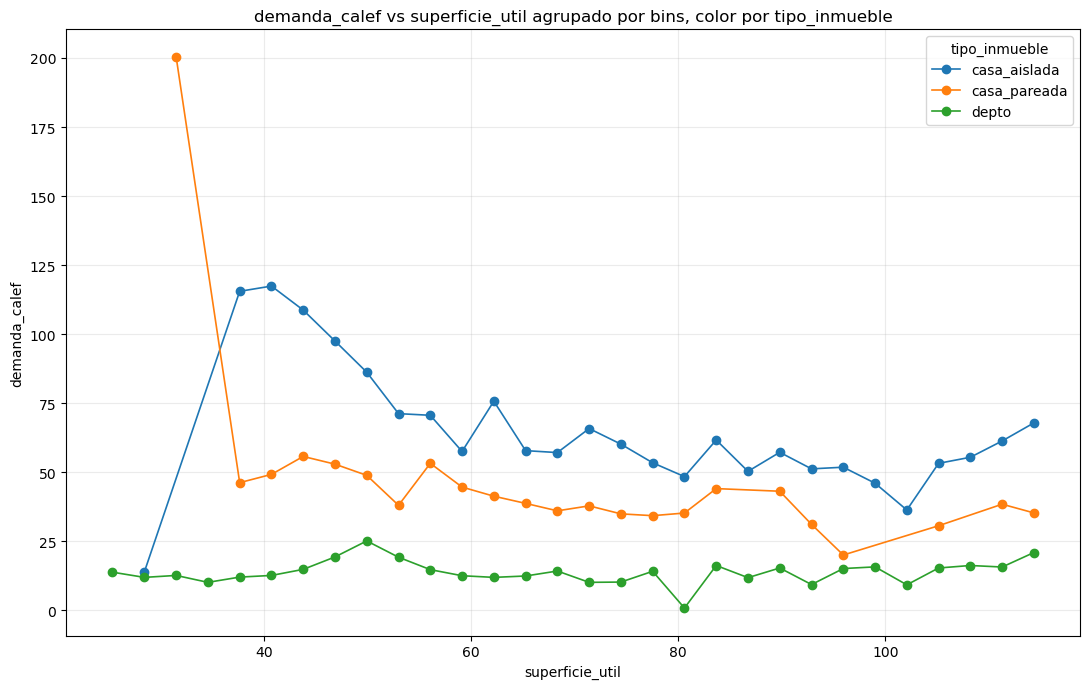

,x_bin,tipo_inmueble,x_mid,y_median,y_mean,y_p10,y_p90,n,x_min,x_max,y_min_original,y_max_original
0,"(23.708, 26.87]",depto,25.289,13.80,16.183638,2.87,31.80,2408,23.8,26.8,0.0,85.6
1,"(26.87, 29.94]",casa_aislada,28.405,13.90,13.900000,13.90,13.90,1,27.2,27.2,13.9,13.9
2,"(26.87, 29.94]",depto,28.405,11.90,14.827175,2.30,29.00,10734,26.9,29.9,0.0,166.4
3,"(29.94, 33.01]",casa_pareada,31.475,200.40,175.976667,87.39,237.77,30,31.3,32.3,77.9,266.0
4,"(29.94, 33.01]",depto,31.475,12.60,15.463735,1.60,31.60,10688,30.0,33.0,0.0,163.5
...,...,...,...,...,...,...,...,...,...,...,...,...
75,"(109.76, 112.83]",casa_pareada,111.295,38.40,38.400000,38.40,38.40,1,110.6,110.6,38.4,38.4
76,"(109.76, 112.83]",depto,111.295,15.65,18.004938,6.81,31.73,162,109.8,112.8,3.9,83.5
77,"(112.83, 115.9]",casa_aislada,114.365,67.85,65.802905,49.60,81.09,482,112.9,115.4,25.9,90.8
78,"(112.83, 115.9]",casa_pareada,114.365,35.25,37.776923,30.75,41.55,26,114.5,115.9,30.3,90.1


## `calef_kwhm2` vs `superficie_util` agrupado por bins

**Variable de color:** `zona_termica`

**Estrategia de bins:** `quantile`

**Registros originales válidos:** 228,924

**Registros después de outliers:** 224,352

**Outliers removidos:** 4,572

**Columnas usadas para filtrar outliers:** `x`

**Rango usado para `superficie_util`:** 23.80 — 115.90

**Archivo guardado:** `/home/cdo/Downloads/CEV_db/outputs_analisis_cev_jupyter/binned_calef_kwhm2_vs_superficie_util_color_zona_termica_quantile_sin_outliers.png`

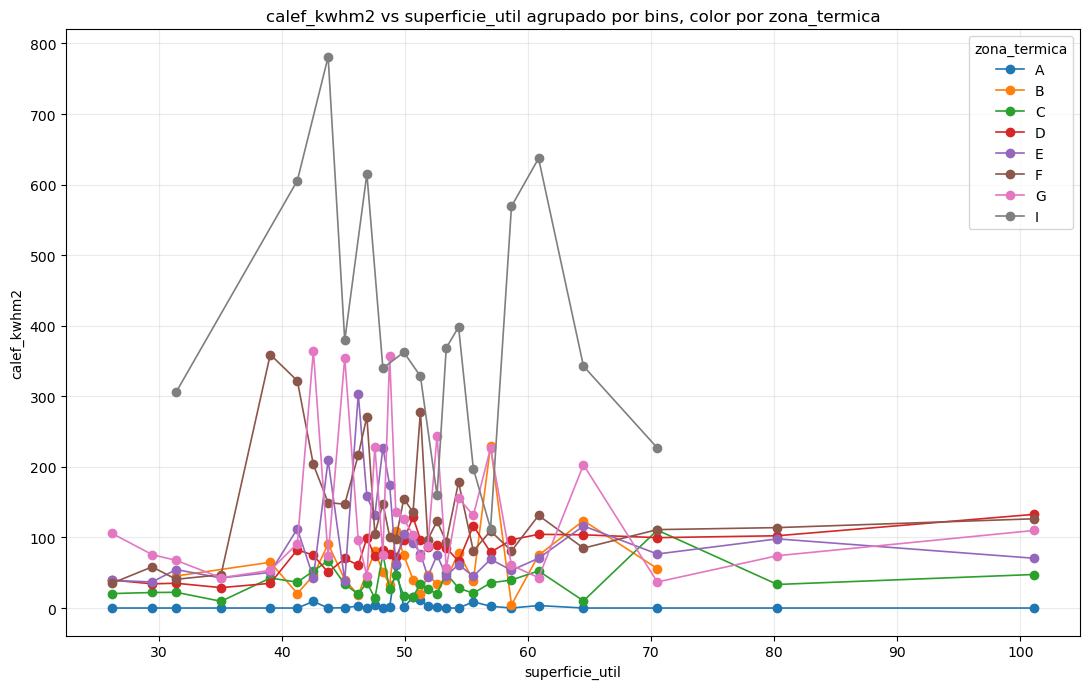

,x_bin,zona_termica,x_mid,y_median,y_mean,y_p10,y_p90,n,x_min,x_max,y_min_original,y_max_original
0,"(23.799, 28.6]",A,26.1995,0.00,14.093939,0.00,43.54,33,27.3,27.8,0.0,131.8
1,"(23.799, 28.6]",C,26.1995,20.50,23.707175,0.00,49.56,223,25.9,28.2,0.0,365.2
2,"(23.799, 28.6]",D,26.1995,39.60,51.337359,0.00,120.39,6732,23.8,28.6,0.0,292.6
3,"(23.799, 28.6]",E,26.1995,39.10,46.000928,0.00,85.00,431,24.8,28.6,0.0,174.3
4,"(23.799, 28.6]",F,26.1995,35.25,49.157143,9.10,122.89,42,24.1,28.6,9.1,182.9
...,...,...,...,...,...,...,...,...,...,...,...,...
216,"(86.3, 115.9]",C,101.1000,47.50,45.787955,1.20,68.40,357,86.5,114.4,0.0,256.8
217,"(86.3, 115.9]",D,101.1000,132.70,125.016173,25.68,210.20,5565,86.4,115.9,0.0,431.8
218,"(86.3, 115.9]",E,101.1000,70.55,72.861220,23.50,108.43,508,87.1,112.6,11.0,207.7
219,"(86.3, 115.9]",F,101.1000,126.45,150.767857,85.90,269.90,756,87.2,114.6,30.2,307.7


## `consumo_kwhm2` vs `superficie_util` agrupado por bins

**Variable de color:** `etiqueta`

**Estrategia de bins:** `quantile`

**Registros originales válidos:** 221,428

**Registros después de outliers:** 217,031

**Outliers removidos:** 4,397

**Columnas usadas para filtrar outliers:** `x`

**Rango usado para `superficie_util`:** 24.10 — 116.10

**Archivo guardado:** `/home/cdo/Downloads/CEV_db/outputs_analisis_cev_jupyter/binned_consumo_kwhm2_vs_superficie_util_color_etiqueta_quantile_sin_outliers.png`

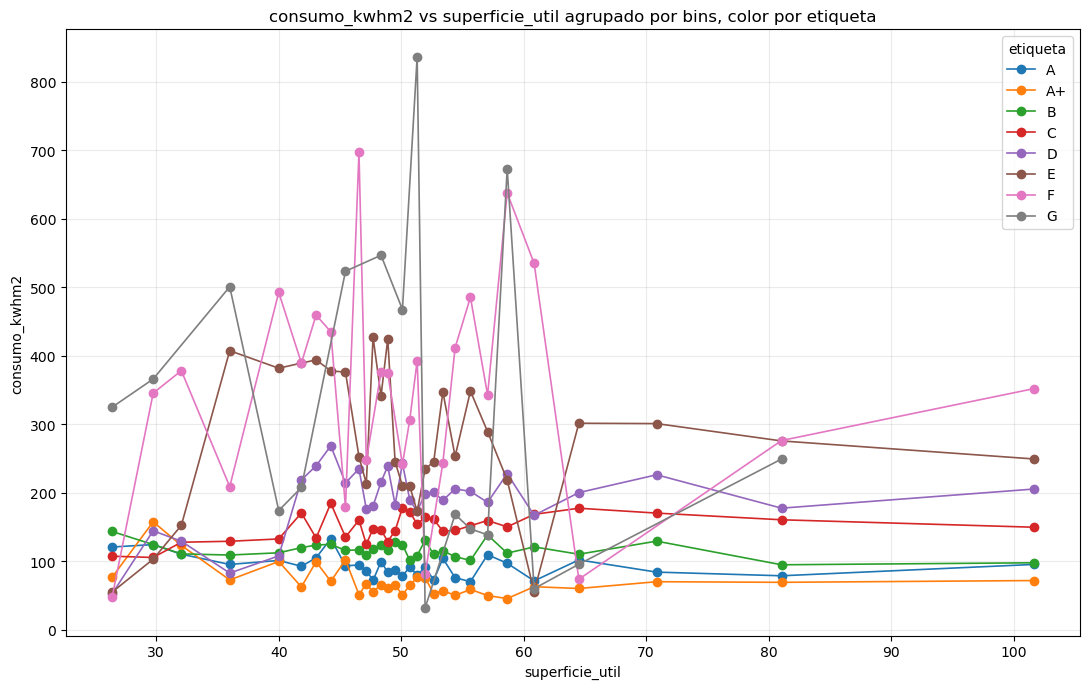

,x_bin,etiqueta,x_mid,y_median,y_mean,y_p10,y_p90,n,x_min,x_max,y_min_original,y_max_original
0,"(24.099, 28.7]",A,26.3995,120.9,247.876773,83.50,399.90,2002,24.1,28.7,51.6,1638.5
1,"(24.099, 28.7]",A+,26.3995,76.8,89.910429,56.10,157.44,163,24.9,28.6,55.9,248.6
2,"(24.099, 28.7]",B,26.3995,143.6,186.458824,80.86,292.36,3587,24.1,28.7,40.4,1639.3
3,"(24.099, 28.7]",C,26.3995,107.5,155.038413,66.60,224.00,1273,24.1,28.7,49.3,1685.7
4,"(24.099, 28.7]",D,26.3995,52.7,79.649080,47.70,155.70,326,24.1,28.7,47.7,601.7
...,...,...,...,...,...,...,...,...,...,...,...,...
218,"(87.2, 116.1]",B,101.6500,97.9,106.155013,63.20,154.20,1147,87.4,115.9,32.6,3213.9
219,"(87.2, 116.1]",C,101.6500,149.8,157.561855,77.14,226.13,2598,87.3,115.9,32.6,358.5
220,"(87.2, 116.1]",D,101.6500,205.5,212.371628,140.70,291.00,2358,87.3,115.4,52.8,3244.2
221,"(87.2, 116.1]",E,101.6500,249.4,245.135059,193.08,304.86,425,87.3,115.4,54.6,320.8


In [18]:
# ============================================================
# BLOQUE 9: Ejemplos de gráficos por bins
# ============================================================

# Superficie útil vs demanda calefacción, coloreado por tipo de vivienda
grouped_sup_tipo = plot_binned_numeric_jupyter_sqlite(
    column="superficie_util",
    target_column="demanda_calef",
    color_column="tipo_inmueble",
    data=df,
    n_bins=30,
    bin_strategy="linear",
    y_log=False,
    remove_outliers=True,
    outlier_quantiles=(0.01, 0.99),
    outlier_columns="x",
)

# Superficie útil vs calef_kwhm2, coloreado por zona térmica
grouped_sup_zona = plot_binned_numeric_jupyter_sqlite(
    column="superficie_util",
    target_column="calef_kwhm2",
    color_column="zona_termica",
    data=df,
    n_bins=30,
    bin_strategy="quantile",
    y_log=False,
    remove_outliers=True,
    outlier_quantiles=(0.01, 0.99),
    outlier_columns="x",
)

# Superficie útil vs consumo_kwhm2, coloreado por etiqueta
grouped_sup_etiqueta = plot_binned_numeric_jupyter_sqlite(
    column="superficie_util",
    target_column="consumo_kwhm2",
    color_column="etiqueta",
    data=df,
    n_bins=30,
    bin_strategy="quantile",
    y_log=False,
    remove_outliers=True,
    outlier_quantiles=(0.01, 0.99),
    outlier_columns="x",
)

## Resumen de relaciones

,relacion,n,media,std,p01,p50,p99,corr
0,calef_proyec_kwh / superficie_util,228973,97.384498,96.910137,0.0,74.383534,381.127143,NaN
1,acs_proyec_kwh / superficie_util,228884,67.395219,681.527420,0.0,50.504167,438.278912,NaN
2,demanda_calef / superficie_util,228973,0.686110,0.718486,0.0,0.530201,2.997449,NaN
3,demanda_refri / superficie_util,228973,0.345055,0.554708,0.0,0.202405,2.088525,NaN
4,"corr(superficie_util, demanda_calef)",228973,NaN,NaN,NaN,NaN,NaN,0.117909
5,"corr(superficie_util, calef_proyec_kwh)",228973,NaN,NaN,NaN,NaN,NaN,0.337623
6,"corr(superficie_util, acs_proyec_kwh)",228884,NaN,NaN,NaN,NaN,NaN,0.005416
7,"corr(calef_proyec_kwh, calef_kwhm2)",228924,NaN,NaN,NaN,NaN,NaN,0.926712
8,"corr(acs_proyec_kwh, acs_kwhm2)",228884,NaN,NaN,NaN,NaN,NaN,0.991342
9,"corr(demanda_calef, calef_kwhm2)",228924,NaN,NaN,NaN,NaN,NaN,0.926612


## Correlaciones altas |corr| >= 0.80

,variable_1,variable_2,corr,abs_corr
2,acs_proyec_kwh,acs_kwhm2,0.991342,0.991342
5,acs_kwhm2,consumo_kwhm2,0.986731,0.986731
3,acs_proyec_kwh,consumo_kwhm2,0.981658,0.981658
1,calef_proyec_kwh,calef_kwhm2,0.926712,0.926712
4,demanda_calef,calef_kwhm2,0.926612,0.926612
0,calef_proyec_kwh,demanda_calef,0.862930,0.862930


**Figura guardada:** `/home/cdo/Downloads/CEV_db/outputs_analisis_cev_jupyter/correlacion_variables_numericas_cev.png`

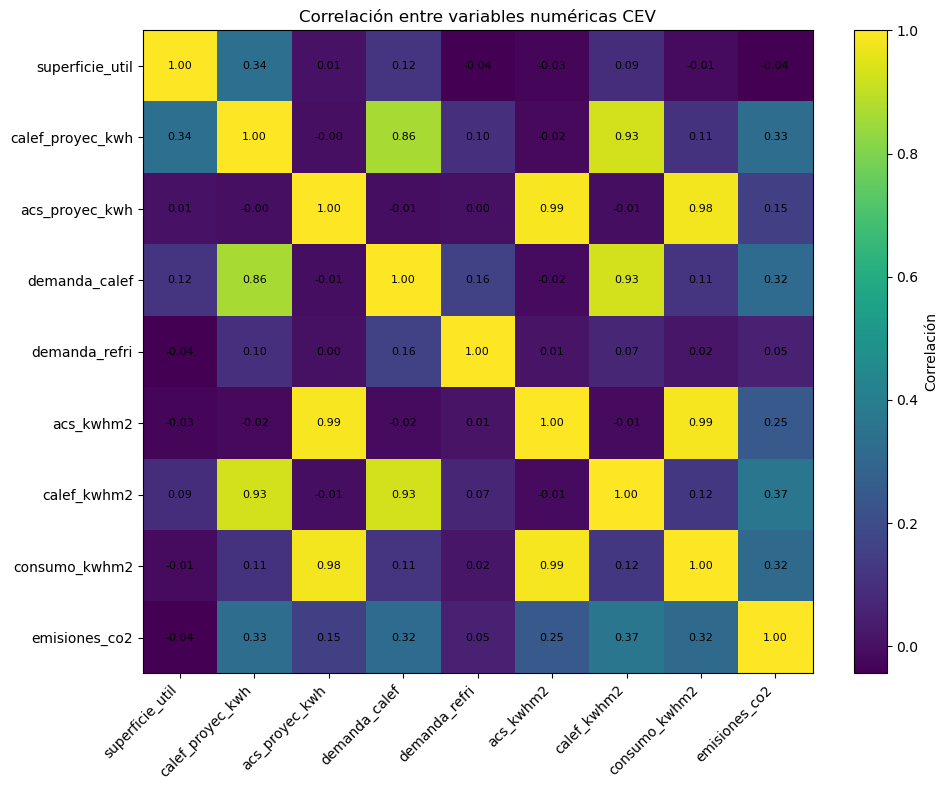

In [19]:
# ============================================================
# BLOQUE 10: Diagnóstico de correlaciones y dependencias
# ============================================================

def diagnostico_dependencias_cev(data=None):
    if data is None:
        data = load_base_dataframe()

    work_df = data.copy()

    for col in NUMERIC_COLUMNS:
        if col in work_df.columns:
            work_df[col] = pd.to_numeric(work_df[col], errors="coerce")

    relation_rows = []

    def add_relation_ratio(name, numerator, denominator):
        mask = (
            work_df[numerator].notna()
            & work_df[denominator].notna()
            & (work_df[denominator] != 0)
        )

        ratio = work_df.loc[mask, numerator] / work_df.loc[mask, denominator]

        relation_rows.append({
            "relacion": name,
            "n": int(mask.sum()),
            "media": ratio.mean(),
            "std": ratio.std(),
            "p01": ratio.quantile(0.01),
            "p50": ratio.quantile(0.50),
            "p99": ratio.quantile(0.99),
        })

    def add_corr(name, col_a, col_b):
        valid = work_df[[col_a, col_b]].dropna()

        relation_rows.append({
            "relacion": name,
            "n": len(valid),
            "corr": valid[col_a].corr(valid[col_b]) if len(valid) > 1 else np.nan,
        })

    # Relaciones físicas / energéticas simples
    add_relation_ratio("calef_proyec_kwh / superficie_util", "calef_proyec_kwh", "superficie_util")
    add_relation_ratio("acs_proyec_kwh / superficie_util", "acs_proyec_kwh", "superficie_util")
    add_relation_ratio("demanda_calef / superficie_util", "demanda_calef", "superficie_util")
    add_relation_ratio("demanda_refri / superficie_util", "demanda_refri", "superficie_util")

    # Correlaciones relevantes
    add_corr("corr(superficie_util, demanda_calef)", "superficie_util", "demanda_calef")
    add_corr("corr(superficie_util, calef_proyec_kwh)", "superficie_util", "calef_proyec_kwh")
    add_corr("corr(superficie_util, acs_proyec_kwh)", "superficie_util", "acs_proyec_kwh")
    add_corr("corr(calef_proyec_kwh, calef_kwhm2)", "calef_proyec_kwh", "calef_kwhm2")
    add_corr("corr(acs_proyec_kwh, acs_kwhm2)", "acs_proyec_kwh", "acs_kwhm2")
    add_corr("corr(demanda_calef, calef_kwhm2)", "demanda_calef", "calef_kwhm2")
    add_corr("corr(consumo_kwhm2, calef_kwhm2)", "consumo_kwhm2", "calef_kwhm2")
    add_corr("corr(consumo_kwhm2, acs_kwhm2)", "consumo_kwhm2", "acs_kwhm2")

    df_rel = pd.DataFrame(relation_rows)

    corr_cols = [
        "superficie_util",
        "calef_proyec_kwh",
        "acs_proyec_kwh",
        "demanda_calef",
        "demanda_refri",
        "acs_kwhm2",
        "calef_kwhm2",
        "consumo_kwhm2",
        "emisiones_co2",
    ]

    corr_cols = [col for col in corr_cols if col in work_df.columns]

    corr_matrix = work_df[corr_cols].corr(numeric_only=True)

    high_corr_rows = []

    for i, col_i in enumerate(corr_matrix.columns):
        for col_j in corr_matrix.columns[i + 1:]:
            corr_value = corr_matrix.loc[col_i, col_j]

            if pd.notna(corr_value) and abs(corr_value) >= 0.80:
                high_corr_rows.append({
                    "variable_1": col_i,
                    "variable_2": col_j,
                    "corr": corr_value,
                    "abs_corr": abs(corr_value),
                })

    df_high_corr = pd.DataFrame(high_corr_rows)

    if not df_high_corr.empty:
        df_high_corr = df_high_corr.sort_values("abs_corr", ascending=False)

    display(Markdown("## Resumen de relaciones"))
    display(df_rel)

    display(Markdown("## Correlaciones altas |corr| >= 0.80"))
    display(df_high_corr)

    # Heatmap con matplotlib
    fig, ax = plt.subplots(figsize=(10, 8))

    im = ax.imshow(corr_matrix, aspect="auto")

    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_yticks(range(len(corr_matrix.index)))

    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr_matrix.index)

    ax.set_title("Correlación entre variables numéricas CEV")

    fig.colorbar(im, ax=ax, label="Correlación")

    for i in range(len(corr_matrix.index)):
        for j in range(len(corr_matrix.columns)):
            value = corr_matrix.iloc[i, j]

            if pd.notna(value):
                ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

    fig.tight_layout()

    out_path = OUTPUT_DIR / "correlacion_variables_numericas_cev.png"
    fig.savefig(out_path, dpi=DPI)

    display(Markdown(f"**Figura guardada:** `{out_path}`"))
    display(fig)

    plt.close(fig)

    return df_rel, df_high_corr, corr_matrix


df_rel, df_high_corr, corr_matrix = diagnostico_dependencias_cev(df)

# Análisis de correlaciones estratificado por tipo_inmueble


## Análisis para: `casa_pareada`

**Registros en este grupo:** 47,957

## Resumen de relaciones

,relacion,n,media,std,p01,p50,p99,corr
0,calef_proyec_kwh / superficie_util,47957,143.739526,101.812174,27.315149,129.248485,566.153584,NaN
1,acs_proyec_kwh / superficie_util,47957,49.705905,10.840737,10.474806,50.674468,65.522184,NaN
2,demanda_calef / superficie_util,47957,1.009190,0.910221,0.255985,0.869469,3.960751,NaN
3,demanda_refri / superficie_util,47957,0.188436,0.681783,0.000000,0.118400,1.060669,NaN
4,"corr(superficie_util, demanda_calef)",47957,NaN,NaN,NaN,NaN,NaN,-0.104361
5,"corr(superficie_util, calef_proyec_kwh)",47957,NaN,NaN,NaN,NaN,NaN,0.147458
6,"corr(superficie_util, acs_proyec_kwh)",47957,NaN,NaN,NaN,NaN,NaN,0.381339
7,"corr(calef_proyec_kwh, calef_kwhm2)",47957,NaN,NaN,NaN,NaN,NaN,0.960618
8,"corr(acs_proyec_kwh, acs_kwhm2)",47957,NaN,NaN,NaN,NaN,NaN,0.603562
9,"corr(demanda_calef, calef_kwhm2)",47957,NaN,NaN,NaN,NaN,NaN,0.911430


## Correlaciones altas |corr| >= 0.80

,variable_1,variable_2,corr,abs_corr
7,calef_kwhm2,consumo_kwhm2,0.994826,0.994826
9,consumo_kwhm2,emisiones_co2,0.980431,0.980431
8,calef_kwhm2,emisiones_co2,0.977400,0.977400
1,calef_proyec_kwh,calef_kwhm2,0.960618,0.960618
3,calef_proyec_kwh,emisiones_co2,0.949309,0.949309
2,calef_proyec_kwh,consumo_kwhm2,0.946678,0.946678
4,demanda_calef,calef_kwhm2,0.911430,0.911430
5,demanda_calef,consumo_kwhm2,0.903345,0.903345
0,calef_proyec_kwh,demanda_calef,0.859089,0.859089
6,demanda_calef,emisiones_co2,0.831441,0.831441


**Figura guardada:** `/home/cdo/Downloads/CEV_db/outputs_analisis_cev_jupyter/correlacion_variables_numericas_cev.png`

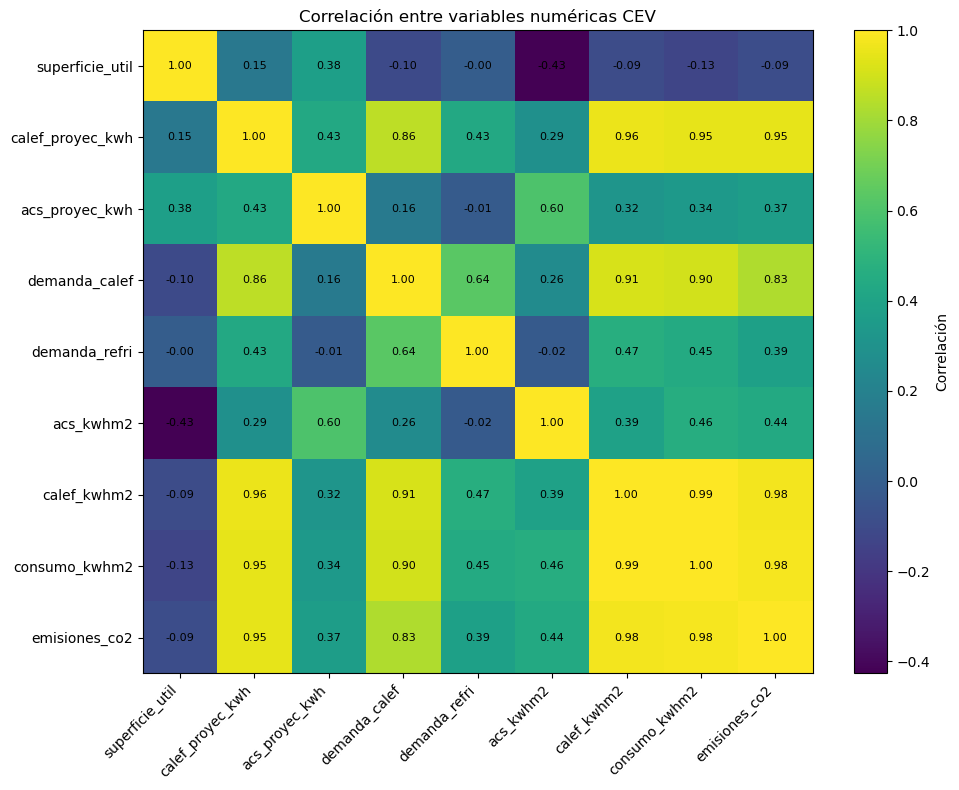

---


## Análisis para: `casa_aislada`

**Registros en este grupo:** 31,008

## Resumen de relaciones

,relacion,n,media,std,p01,p50,p99,corr
0,calef_proyec_kwh / superficie_util,31008,208.835963,132.309065,29.638817,188.806265,443.019023,NaN
1,acs_proyec_kwh / superficie_util,31005,60.182521,1772.499660,12.210797,50.960000,68.114000,NaN
2,demanda_calef / superficie_util,31008,1.344204,0.964401,0.174677,1.047619,3.655167,NaN
3,demanda_refri / superficie_util,31008,0.165742,0.440625,0.000000,0.090759,0.799197,NaN
4,"corr(superficie_util, demanda_calef)",31008,NaN,NaN,NaN,NaN,NaN,-0.412571
5,"corr(superficie_util, calef_proyec_kwh)",31008,NaN,NaN,NaN,NaN,NaN,0.087460
6,"corr(superficie_util, acs_proyec_kwh)",31005,NaN,NaN,NaN,NaN,NaN,0.002776
7,"corr(calef_proyec_kwh, calef_kwhm2)",31005,NaN,NaN,NaN,NaN,NaN,0.823960
8,"corr(acs_proyec_kwh, acs_kwhm2)",31005,NaN,NaN,NaN,NaN,NaN,0.999938
9,"corr(demanda_calef, calef_kwhm2)",31005,NaN,NaN,NaN,NaN,NaN,0.913778


## Correlaciones altas |corr| >= 0.80

,variable_1,variable_2,corr,abs_corr
1,acs_proyec_kwh,acs_kwhm2,0.999938,0.999938
5,acs_kwhm2,consumo_kwhm2,0.997246,0.997246
2,acs_proyec_kwh,consumo_kwhm2,0.996832,0.996832
6,calef_kwhm2,emisiones_co2,0.958061,0.958061
3,demanda_calef,calef_kwhm2,0.913778,0.913778
4,demanda_calef,emisiones_co2,0.835595,0.835595
0,calef_proyec_kwh,calef_kwhm2,0.823960,0.823960


**Figura guardada:** `/home/cdo/Downloads/CEV_db/outputs_analisis_cev_jupyter/correlacion_variables_numericas_cev.png`

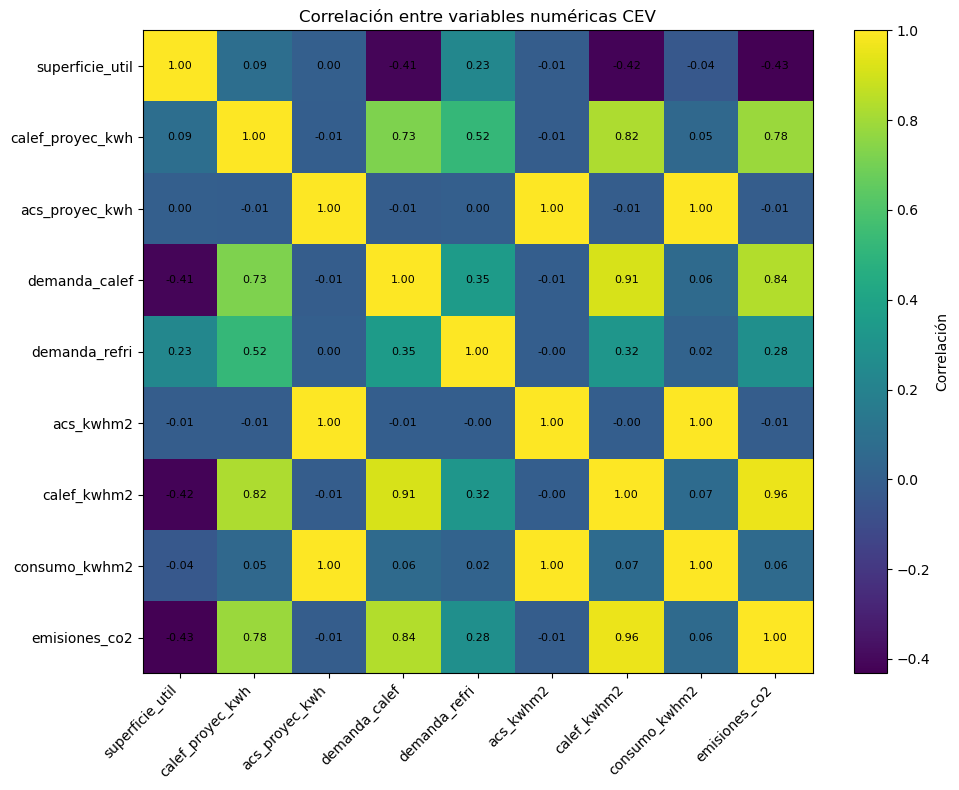

---


## Análisis para: `depto`

**Registros en este grupo:** 149,638

## Resumen de relaciones

,relacion,n,media,std,p01,p50,p99,corr
0,calef_proyec_kwh / superficie_util,149638,59.367618,51.621091,0.0,46.279459,225.024725,NaN
1,acs_proyec_kwh / superficie_util,149552,74.602975,243.597581,0.0,50.360082,772.180163,NaN
2,demanda_calef / superficie_util,149638,0.445644,0.384763,0.0,0.353909,1.697337,NaN
3,demanda_refri / superficie_util,149638,0.432930,0.509150,0.0,0.275554,2.292627,NaN
4,"corr(superficie_util, demanda_calef)",149638,NaN,NaN,NaN,NaN,NaN,0.062145
5,"corr(superficie_util, calef_proyec_kwh)",149638,NaN,NaN,NaN,NaN,NaN,0.222050
6,"corr(superficie_util, acs_proyec_kwh)",149552,NaN,NaN,NaN,NaN,NaN,0.014865
7,"corr(calef_proyec_kwh, calef_kwhm2)",149592,NaN,NaN,NaN,NaN,NaN,0.905178
8,"corr(acs_proyec_kwh, acs_kwhm2)",149552,NaN,NaN,NaN,NaN,NaN,0.939791
9,"corr(demanda_calef, calef_kwhm2)",149592,NaN,NaN,NaN,NaN,NaN,0.887198


## Correlaciones altas |corr| >= 0.80

,variable_1,variable_2,corr,abs_corr
8,consumo_kwhm2,emisiones_co2,0.990981,0.990981
2,acs_proyec_kwh,acs_kwhm2,0.939791,0.939791
6,acs_kwhm2,consumo_kwhm2,0.938142,0.938142
3,acs_proyec_kwh,consumo_kwhm2,0.910791,0.910791
1,calef_proyec_kwh,calef_kwhm2,0.905178,0.905178
7,acs_kwhm2,emisiones_co2,0.903351,0.903351
5,demanda_calef,calef_kwhm2,0.887198,0.887198
4,acs_proyec_kwh,emisiones_co2,0.834972,0.834972
0,calef_proyec_kwh,demanda_calef,0.813153,0.813153


**Figura guardada:** `/home/cdo/Downloads/CEV_db/outputs_analisis_cev_jupyter/correlacion_variables_numericas_cev.png`

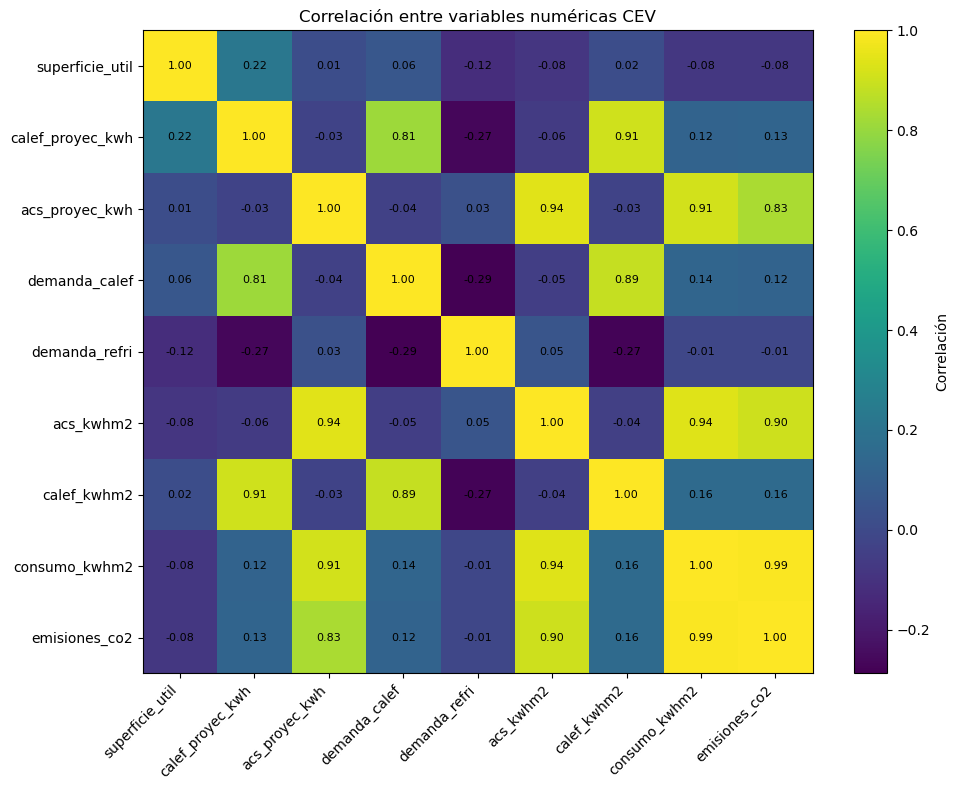

---


✓ Análisis estratificado completado

In [20]:
# ============================================================
# BLOQUE 10b: Análisis de correlaciones por tipo de inmueble
# ============================================================

display(Markdown("# Análisis de correlaciones estratificado por tipo_inmueble"))

tipo_inmueble_categorias = ['casa_pareada', 'casa_aislada', 'depto']
results_by_tipo = {}

for tipo_cat in tipo_inmueble_categorias:
    display(Markdown(f"\n## Análisis para: `{tipo_cat}`"))
    
    # Filtrar datos
    df_filtered = df[df['tipo_inmueble'] == tipo_cat].copy()
    
    n_registros = len(df_filtered)
    display(Markdown(f"**Registros en este grupo:** {n_registros:,}"))
    
    if n_registros < 10:
        display(Markdown(f"⚠ Muy pocos registros ({n_registros}) para análisis de correlación"))
        continue
    
    # Ejecutar análisis
    df_rel, df_high_corr, corr_matrix = diagnostico_dependencias_cev(df_filtered)
    
    results_by_tipo[tipo_cat] = {
        'df_rel': df_rel,
        'df_high_corr': df_high_corr,
        'corr_matrix': corr_matrix,
        'n_registros': n_registros
    }
    
    display(Markdown("---"))

display(Markdown("\n✓ Análisis estratificado completado"))


In [26]:
# ============================================================
# BLOQUE 11: PCA con One-Hot Encoding
# ============================================================

def pca_cev_sqlite(
    data=None,
    target_column="consumo_kwhm2",
    sample_n=None,
    n_components=5,
    remove_outliers=True,
    outlier_quantiles=(0.01, 0.99),
    top_loadings_n=15,
):
    """
    PCA usando variables mixtas mediante:
    - StandardScaler para numéricas.
    - OneHotEncoder para categóricas.

    Nota:
    El target_column NO entra como variable explicativa.
    Se usa solo para colorear e interpretar los componentes.
    """

    if data is None:
        data = load_base_dataframe(sample_n=sample_n)
    else:
        data = data.copy()

    if sample_n is not None and data is not None:
        data = data.sample(
            n=min(sample_n, len(data)),
            random_state=RANDOM_STATE,
        )

    if target_column not in data.columns:
        raise ValueError(f"No existe target_column={target_column}")

    excluded_columns = {
        target_column,
        "demanda_calef",
        "demanda_refri",
        "etiqueta",
        "materialidad",
        "document_id",
        "source_pdf",
        "direccion",
        "fecha_emision",
        "rol_vivienda",
    }

    numeric_features = [
        col for col in NUMERIC_COLUMNS
        if col in data.columns and col not in excluded_columns
    ]

    numeric_features = [
        col for col in numeric_features
        if data[col].notna().any()
    ]

    numeric_features += [
        col for col in data.columns
        if col not in excluded_columns
        and col not in numeric_features
        and pd.api.types.is_numeric_dtype(data[col])
        and data[col].notna().any()
    ]

    categorical_features = [
        col for col in CATEGORICAL_COLUMNS
        if col in data.columns and col not in excluded_columns
    ]

    categorical_features = [
        col for col in categorical_features
        if data[col].notna().any()
    ]

    categorical_features += [
        col for col in data.columns
        if col not in excluded_columns
        and col not in categorical_features
        and pd.api.types.is_string_dtype(data[col])
        and data[col].notna().any()
    ]

    for col in numeric_features + [target_column]:
        data[col] = pd.to_numeric(data[col], errors="coerce")

    for col in categorical_features:
        data[col] = data[col].fillna("missing").astype(str).str.strip()
        if col == "tipo_inmueble":
            data[col] = data[col].replace("missing", "indeterminado")

    data = data.dropna(subset=[target_column]).copy()

    if remove_outliers:
        q_low, q_high = outlier_quantiles

        y_low = data[target_column].quantile(q_low)
        y_high = data[target_column].quantile(q_high)

        data = data[
            data[target_column].between(y_low, y_high, inclusive="both")
        ].copy()

    numeric_features = [
        col for col in numeric_features
        if col in data.columns and data[col].notna().any()
    ]

    categorical_features = [
        col for col in categorical_features
        if col in data.columns and data[col].notna().any()
    ]

    feature_cols = numeric_features + categorical_features

    if len(feature_cols) == 0:
        raise ValueError("No hay variables explicativas válidas para PCA.")

    if len(data) < 3:
        raise ValueError("Muy pocos datos válidos para PCA.")

    try:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                numeric_features,
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", encoder),
                ]),
                categorical_features,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    X = preprocessor.fit_transform(data[feature_cols])

    n_components = min(n_components, X.shape[1], X.shape[0] - 1)

    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    components = pca.fit_transform(X)

    pca_cols = [f"PC{i}" for i in range(1, n_components + 1)]

    df_scores = pd.DataFrame(components, columns=pca_cols, index=data.index)
    df_scores[target_column] = data[target_column].values

    feature_names = preprocessor.get_feature_names_out()

    def clean_feature_name(name):
        if name.startswith("tipo_inmueble_"):
            return "tipo_inmueble"
        if name.startswith("zona_termica_"):
            return "zona_termica"
        return name

    cleaned_feature_names = [clean_feature_name(name) for name in feature_names]

    df_loadings = pd.DataFrame(
        pca.components_.T,
        index=cleaned_feature_names,
        columns=pca_cols,
    )

    def aggregate_loadings(loadings, pc):
        grouped = loadings[pc].abs().groupby(loadings.index).sum()
        rows = []
        for variable, abs_sum in grouped.items():
            values = loadings.loc[variable, pc]
            if isinstance(values, pd.Series):
                sign_value = values.iloc[values.abs().argmax()]
            else:
                sign_value = values
            rows.append((variable, sign_value, abs_sum))
        return pd.DataFrame(rows, columns=["variable", "loading", "abs_loading"]).set_index("variable")

    df_variance = pd.DataFrame({
        "componente": pca_cols,
        "varianza_explicada": pca.explained_variance_ratio_,
        "varianza_acumulada": np.cumsum(pca.explained_variance_ratio_),
    })

    df_corr_target = (
        df_scores[pca_cols + [target_column]]
        .corr(numeric_only=True)[target_column]
        .drop(target_column)
        .rename("correlacion_con_target")
        .to_frame()
    )

    top_loadings = []

    for pc in pca_cols:
        agg = aggregate_loadings(df_loadings, pc)
        top = agg.sort_values("abs_loading", ascending=False).head(top_loadings_n)

        top_loadings.append(pd.DataFrame({
            "componente": pc,
            "variable": top.index,
            "loading": top["loading"].values,
            "abs_loading": top["abs_loading"].values,
        }))

    df_top_loadings = pd.concat(top_loadings, ignore_index=True)

    display(Markdown("## PCA CEV"))
    display(Markdown(f"**Filas usadas:** {len(data):,}"))
    display(Markdown(f"**Target usado solo para interpretación/color:** `{target_column}`"))
    display(Markdown(f"**Variables numéricas usadas:** `{numeric_features}`"))
    display(Markdown(f"**Variables categóricas usadas:** `{categorical_features}`"))

    display(Markdown("### Varianza explicada"))
    display(df_variance)

    display(Markdown("### Correlación de PCs con target"))
    display(df_corr_target)

    display(Markdown("### Variables con mayor loading absoluto"))
    display(df_top_loadings)

    # Gráfico varianza
    fig, ax = plt.subplots(figsize=(9, 6))

    ax.bar(
        df_variance["componente"],
        df_variance["varianza_explicada"],
        label="Individual",
    )

    ax.plot(
        df_variance["componente"],
        df_variance["varianza_acumulada"],
        marker="o",
        label="Acumulada",
    )

    ax.set_title("Varianza explicada por componente")
    ax.set_ylabel("Proporción de varianza")
    ax.grid(alpha=0.25)
    ax.legend()

    fig.tight_layout()

    out_path_var = OUTPUT_DIR / f"pca_varianza_{target_column}.png"
    fig.savefig(out_path_var, dpi=DPI)

    display(Markdown(f"**Figura guardada:** `{out_path_var}`"))
    display(fig)

    plt.close(fig)

    # Scatter PC1-PC2
    if "PC1" in df_scores.columns and "PC2" in df_scores.columns:
        fig, ax = plt.subplots(figsize=(9, 7))

        color_values = np.log1p(df_scores[target_column].clip(lower=0))

        scatter = ax.scatter(
            df_scores["PC1"],
            df_scores["PC2"],
            c=color_values,
            s=4,
            alpha=0.35,
        )

        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.set_title(f"PCA coloreado por log1p({target_column})")
        ax.grid(alpha=0.25)

        fig.colorbar(scatter, ax=ax, label=f"log1p({target_column})")

        fig.tight_layout()

        out_path_scatter = OUTPUT_DIR / f"pca_pc1_pc2_{target_column}.png"
        fig.savefig(out_path_scatter, dpi=DPI)

        display(Markdown(f"**Figura guardada:** `{out_path_scatter}`"))
        display(fig)

        plt.close(fig)

    # Gráfico loadings
    fig, axes = plt.subplots(
        n_components,
        1,
        figsize=(12, max(3.2 * n_components, 5)),
        sharex=False,
    )

    if n_components == 1:
        axes = [axes]

    for ax, pc in zip(axes, pca_cols):
        plot_df = (
            df_top_loadings[df_top_loadings["componente"] == pc]
            .sort_values("abs_loading", ascending=True)
            .copy()
        )

        ax.barh(plot_df["variable"], plot_df["loading"])
        ax.axvline(0, linewidth=0.8)
        ax.set_title(f"{pc}: variables con mayor loading absoluto")
        ax.set_xlabel("Loading")
        ax.grid(axis="x", alpha=0.2)

    fig.tight_layout()

    out_path_loadings = OUTPUT_DIR / f"pca_loadings_{target_column}.png"
    fig.savefig(out_path_loadings, dpi=DPI)

    display(Markdown(f"**Figura guardada:** `{out_path_loadings}`"))
    display(fig)

    plt.close(fig)

    return df_scores, df_loadings, df_variance, df_corr_target, df_top_loadings


def pca_por_tipo_inmueble(
    data,
    target_column="consumo_kwhm2",
    tipos=None,
    **kwargs,
):
    if tipos is None:
        tipos = ["casa_aislada", "casa_pareada", "depto"]

    mapping = {
        "casa_aislada": ["casa_aislada", "casa aislada"],
        "casa_pareada": ["casa_pareada", "casa pareada"],
        "depto": ["depto", "departamento"],
    }

    resultados = {}

    tipo_col = data["tipo_inmueble"].fillna("missing").astype(str).str.lower().str.strip()

    for tipo in tipos:
        valores = mapping.get(tipo, [tipo])
        filtro = tipo_col.isin(valores)
        subset = data.loc[filtro].copy()

        display(Markdown(f"## PCA para tipo_inmueble = {tipo}"))
        if subset.empty:
            display(Markdown(f"No hay registros para {tipo}."))
            continue

        resultados[tipo] = pca_cev_sqlite(
            data=subset,
            target_column=target_column,
            **kwargs,
        )

    return resultados

## PCA CEV

**Filas usadas:** 198,005

**Target usado solo para interpretación/color:** `demanda_calef`

**Variables numéricas usadas:** `['superficie_util', 'ahorro', 'calef_proyec_kwh', 'acs_proyec_kwh', 'acs_kwhm2', 'calef_kwhm2', 'consumo_kwhm2', 'emisiones_co2']`

**Variables categóricas usadas:** `['estado_cev', 'region', 'comuna', 'tipo_inmueble', 'zona_termica']`

...

### Correlación de PCs con target

,correlacion_con_target
PC1,0.357491
PC2,0.830254
PC3,-0.108116
PC4,-0.160236
PC5,0.113383


### Variables con mayor loading absoluto

,componente,variable,loading,abs_loading
0,PC1,consumo_kwhm2,0.536042,0.536042
1,PC1,acs_kwhm2,0.514623,0.514623
2,PC1,acs_proyec_kwh,0.510152,0.510152
3,PC1,emisiones_co2,0.240827,0.240827
4,PC1,calef_kwhm2,0.213769,0.213769
...,...,...,...,...
70,PC5,region_Región del Biobío,0.125216,0.125216
71,PC5,region_Región de la Araucanía,0.075203,0.075203
72,PC5,region_Región de Coquimbo,0.071346,0.071346
73,PC5,comuna_Temuco,0.050823,0.050823


**Figura guardada:** `/home/cdo/Downloads/CEV_db/outputs_analisis_cev_jupyter/pca_varianza_demanda_calef.png`

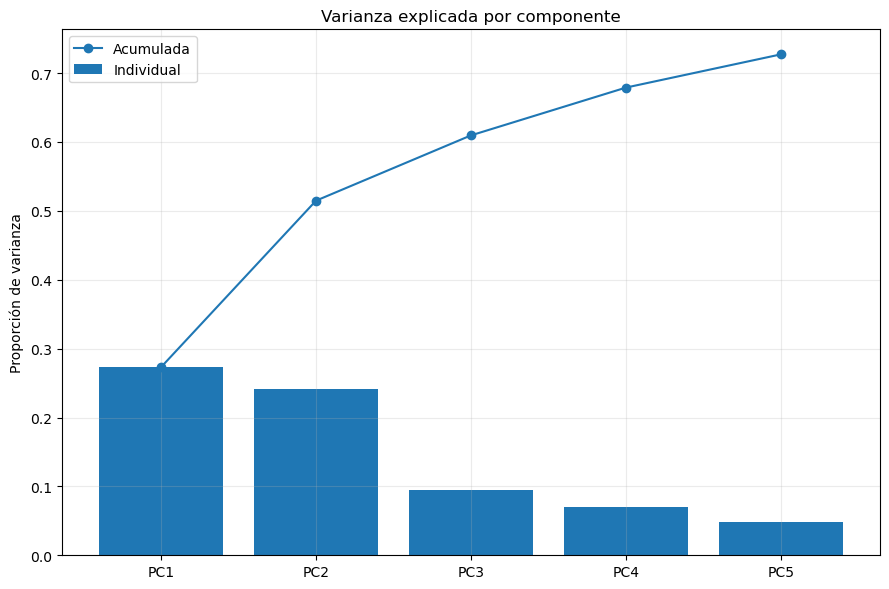

**Figura guardada:** `/home/cdo/Downloads/CEV_db/outputs_analisis_cev_jupyter/pca_pc1_pc2_demanda_calef.png`

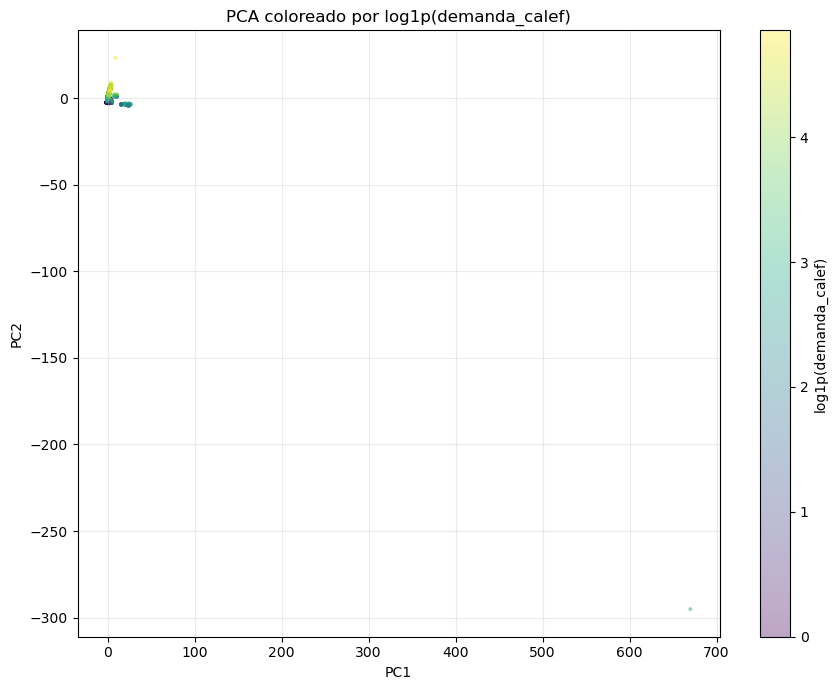

**Figura guardada:** `/home/cdo/Downloads/CEV_db/outputs_analisis_cev_jupyter/pca_loadings_demanda_calef.png`

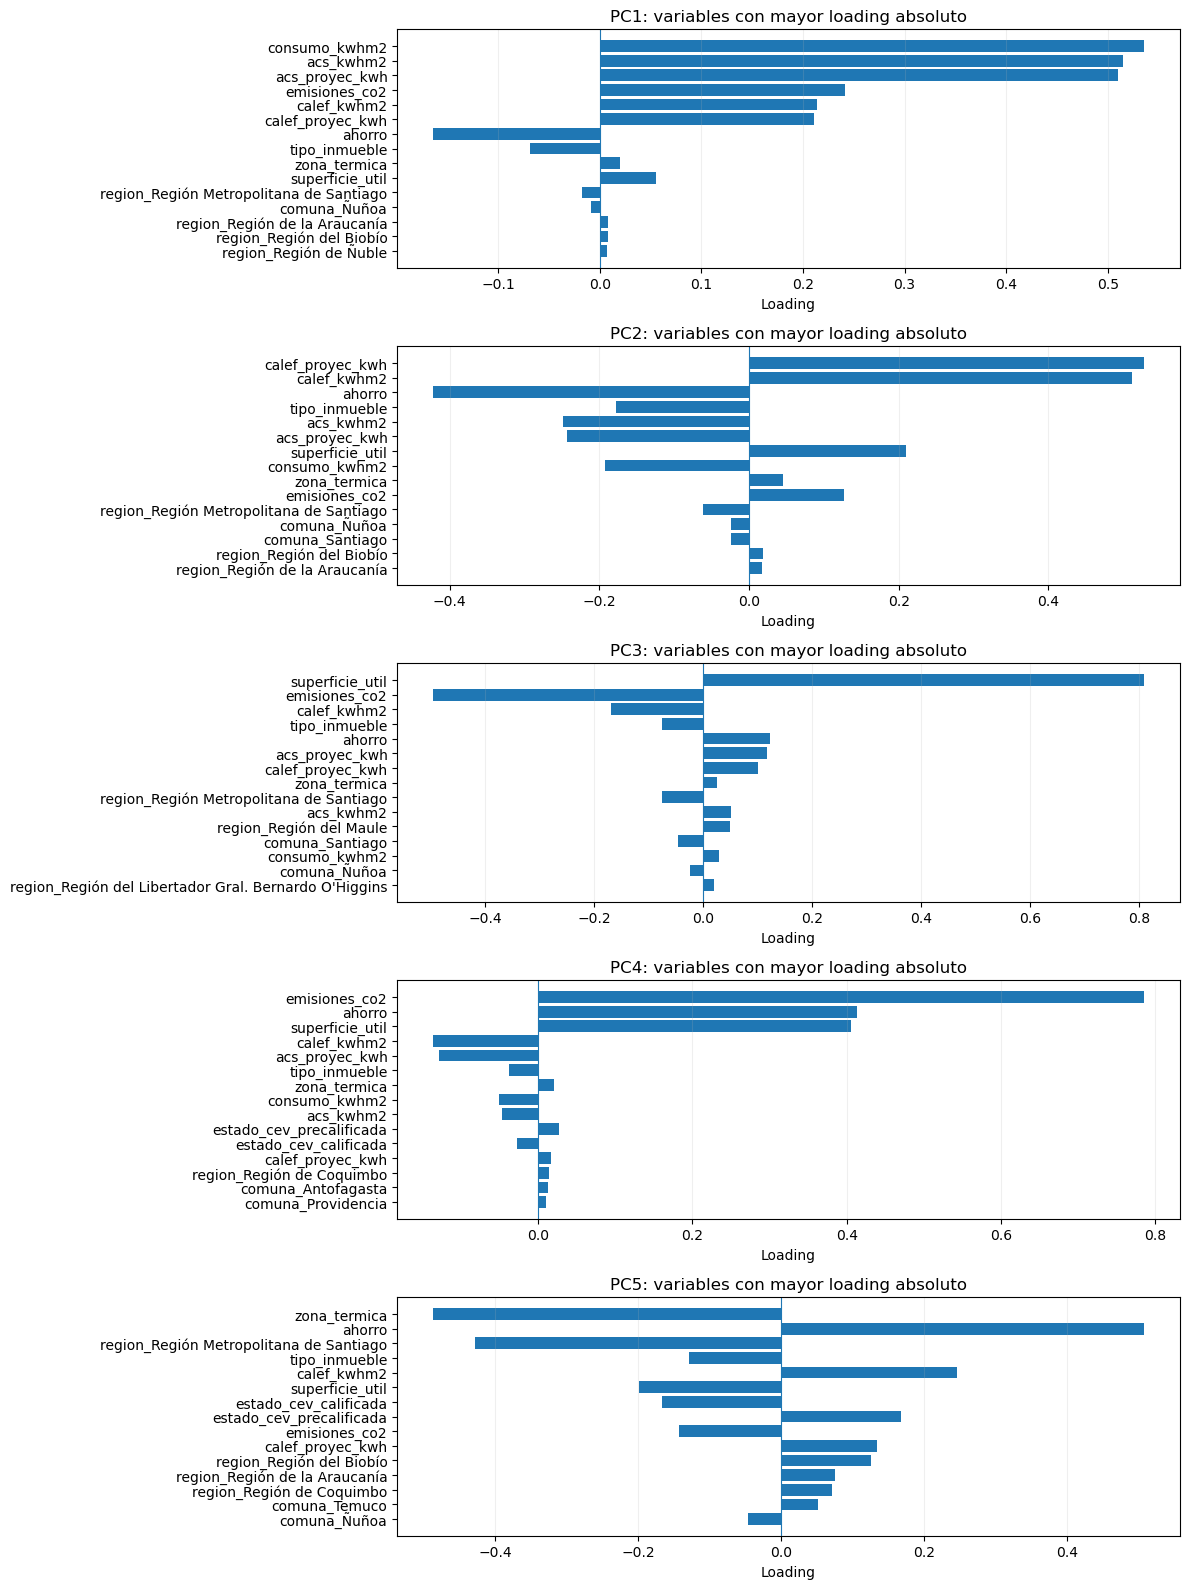

In [27]:
# ============================================================
# BLOQUE 12: Ejecutar PCA
# ============================================================

df_scores, df_loadings, df_variance, df_corr_target, df_top_loadings = pca_cev_sqlite(
    data=df,
    target_column="demanda_calef",
    sample_n=200_000,
    n_components=5,
    remove_outliers=True,
    outlier_quantiles=(0.01, 0.99),
    top_loadings_n=15,
)

# PCA Estratificado por Tipo de Inmueble

Análisis separado para cada categoría: casa_aislada, casa_pareada, depto

## PCA para tipo_inmueble = casa_aislada

## PCA CEV

**Filas usadas:** 30,392

...

### Correlación de PCs con target

,correlacion_con_target
PC1,0.880450
PC2,-0.078705
PC3,-0.133226
PC4,-0.182538
PC5,-0.028843


### Variables con mayor loading absoluto

,componente,variable,loading,abs_loading
0,PC1,calef_kwhm2,0.533865,0.533865
1,PC1,emisiones_co2,0.514912,0.514912
2,PC1,ahorro,-0.433244,0.433244
3,PC1,calef_proyec_kwh,0.386891,0.386891
4,PC1,superficie_util,-0.278315,0.278315
...,...,...,...,...
70,PC5,region_Región de Los Lagos,-0.069664,0.069664
71,PC5,comuna_Temuco,0.065541,0.065541
72,PC5,region_Región del Biobío,0.061926,0.061926
73,PC5,comuna_Lampa,-0.057755,0.057755


**Figura guardada:** `/home/cdo/Downloads/CEV_db/outputs_analisis_cev_jupyter/pca_varianza_demanda_calef.png`

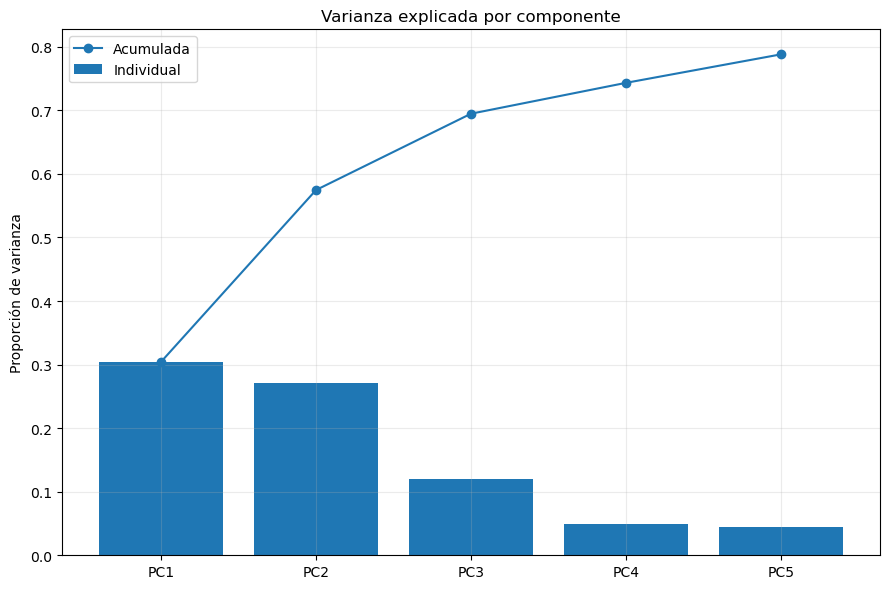

**Figura guardada:** `/home/cdo/Downloads/CEV_db/outputs_analisis_cev_jupyter/pca_pc1_pc2_demanda_calef.png`

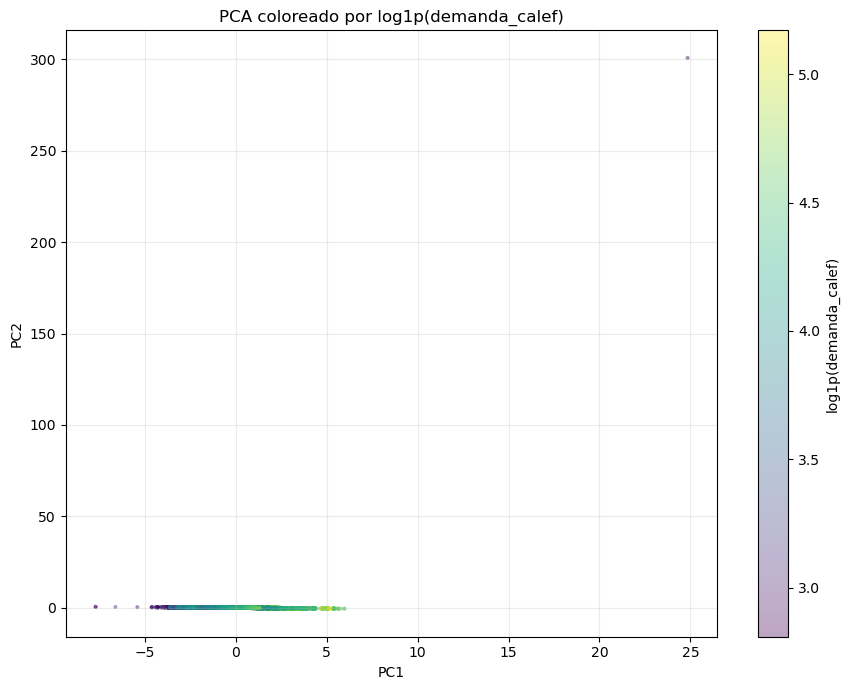

**Figura guardada:** `/home/cdo/Downloads/CEV_db/outputs_analisis_cev_jupyter/pca_loadings_demanda_calef.png`

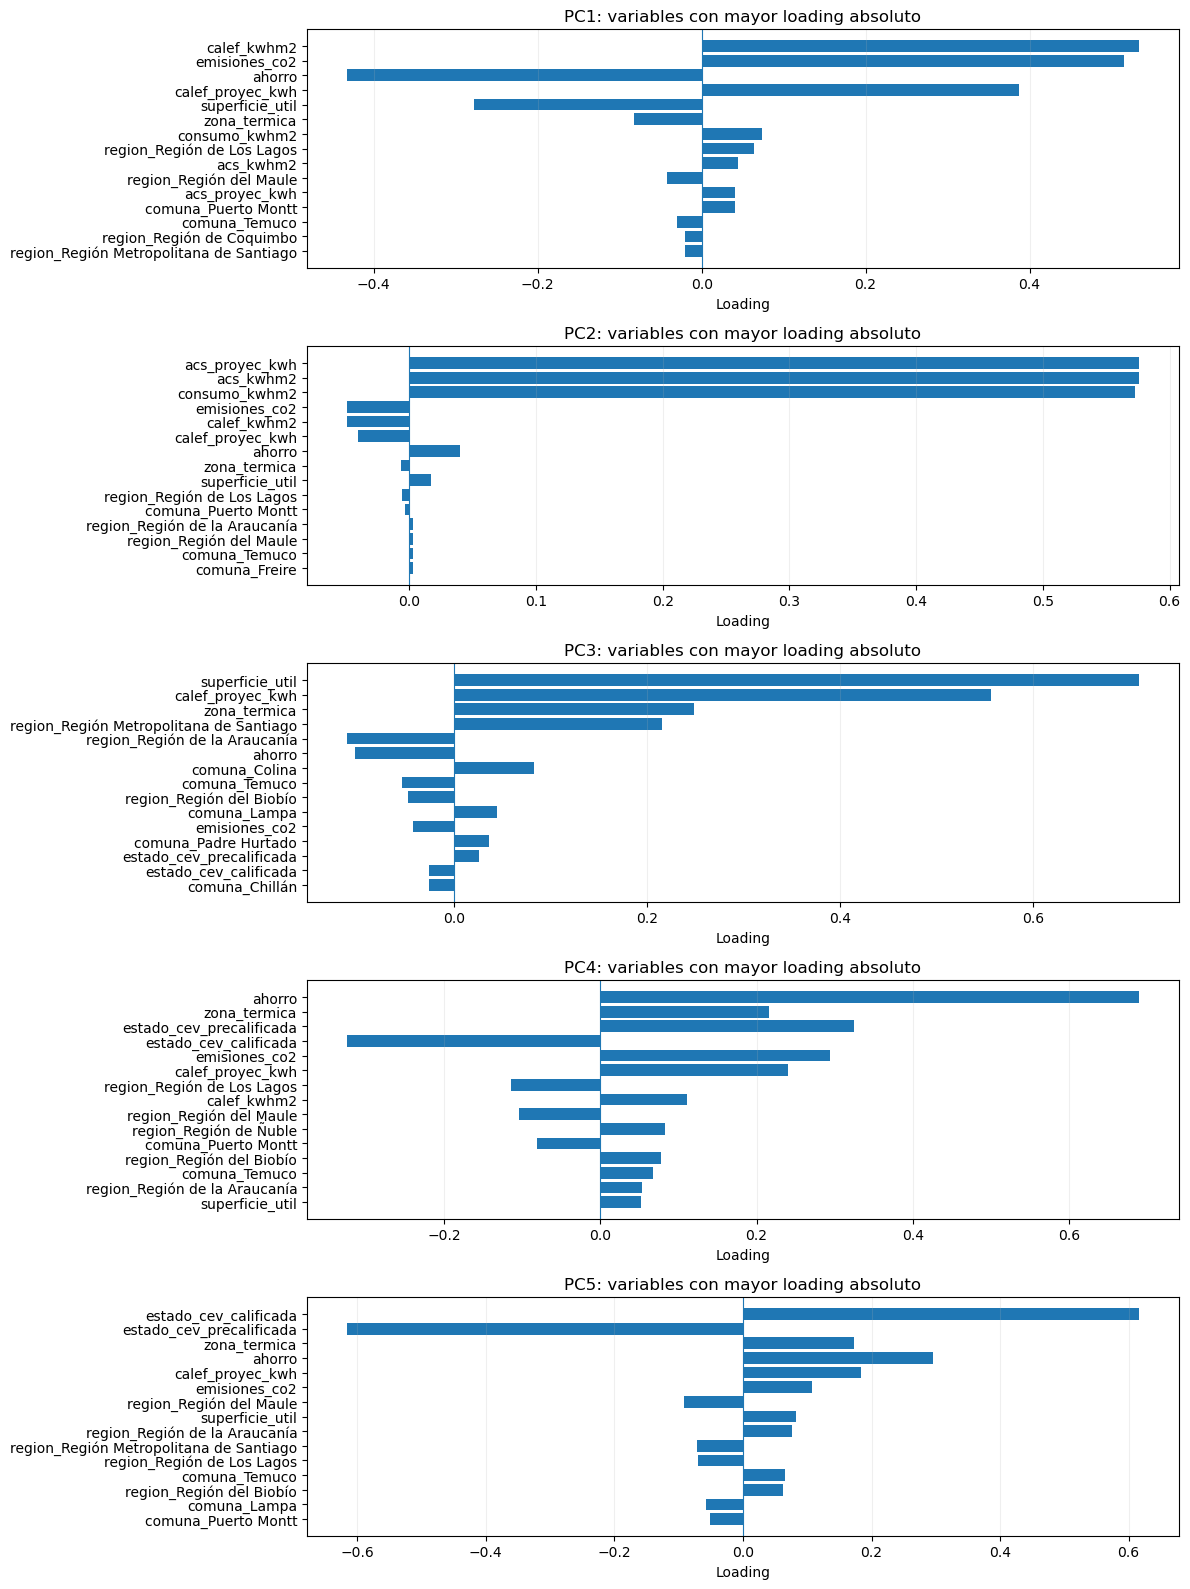

## PCA para tipo_inmueble = casa_pareada

## PCA CEV

**Filas usadas:** 47,009

**Target usado solo para interpretación/color:** `demanda_calef`

**Variables numéricas usadas:** `['superficie_util', 'ahorro', 'calef_proyec_kwh', 'acs_proyec_kwh', 'acs_kwhm2', 'calef_kwhm2', 'consumo_kwhm2', 'emisiones_co2']`

...

### Correlación de PCs con target

,correlacion_con_target
PC1,0.822437
PC2,-0.149755
PC3,-0.274223
PC4,-0.077839
PC5,-0.097974


### Variables con mayor loading absoluto

,componente,variable,loading,abs_loading
0,PC1,consumo_kwhm2,0.440976,0.440976
1,PC1,calef_kwhm2,0.438388,0.438388
2,PC1,emisiones_co2,0.433537,0.433537
3,PC1,calef_proyec_kwh,0.410142,0.410142
4,PC1,ahorro,-0.321960,0.321960
...,...,...,...,...
70,PC5,consumo_kwhm2,0.135452,0.135452
71,PC5,region_Región de la Araucanía,0.078150,0.078150
72,PC5,superficie_util,-0.067179,0.067179
73,PC5,region_Región de Coquimbo,0.059156,0.059156


**Figura guardada:** `/home/cdo/Downloads/CEV_db/outputs_analisis_cev_jupyter/pca_varianza_demanda_calef.png`

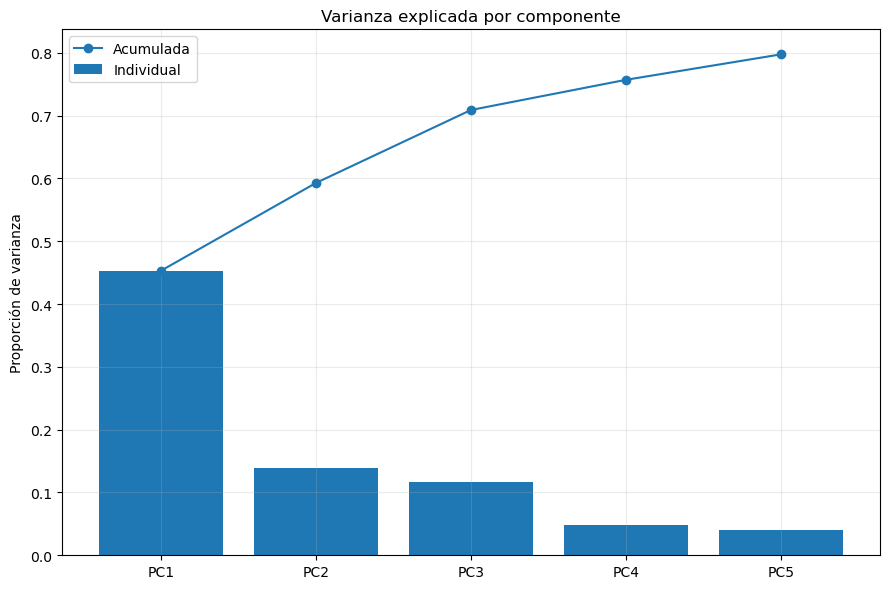

**Figura guardada:** `/home/cdo/Downloads/CEV_db/outputs_analisis_cev_jupyter/pca_pc1_pc2_demanda_calef.png`

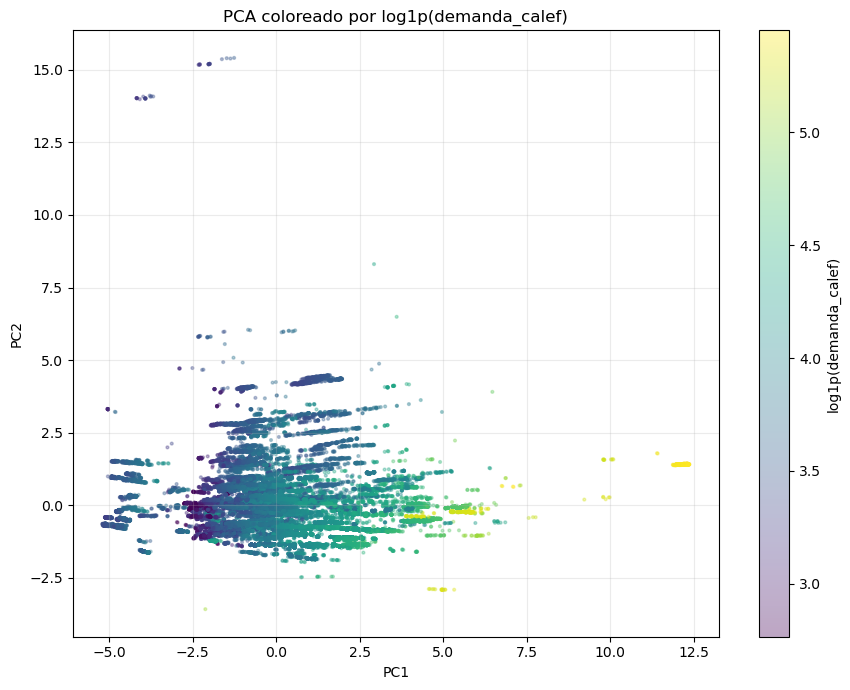

**Figura guardada:** `/home/cdo/Downloads/CEV_db/outputs_analisis_cev_jupyter/pca_loadings_demanda_calef.png`

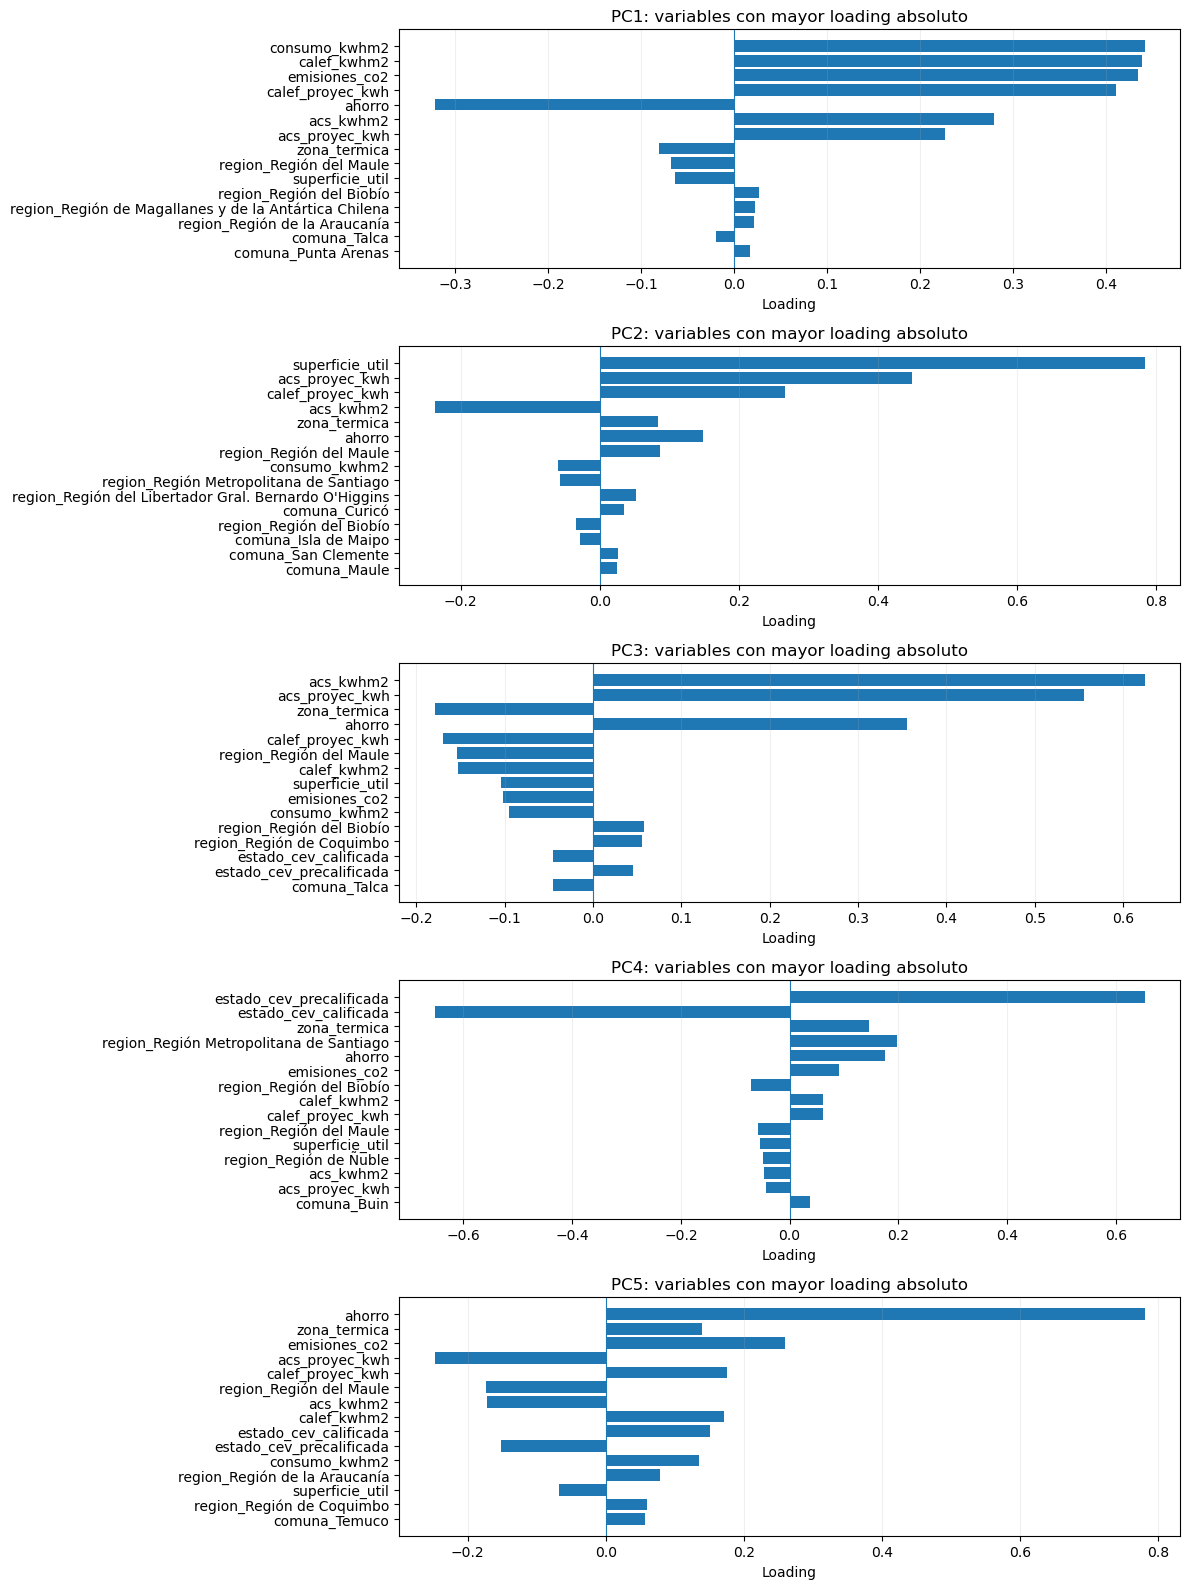

## PCA para tipo_inmueble = depto

## PCA CEV

**Filas usadas:** 148,150

**Target usado solo para interpretación/color:** `demanda_calef`

**Variables numéricas usadas:** `['superficie_util', 'ahorro', 'calef_proyec_kwh', 'acs_proyec_kwh', 'acs_kwhm2', 'calef_kwhm2', 'consumo_kwhm2', 'emisiones_co2']`

...

### Correlación de PCs con target

,correlacion_con_target
PC1,0.091370
PC2,0.879210
PC3,-0.117926
PC4,0.102034
PC5,-0.071835


### Variables con mayor loading absoluto

,componente,variable,loading,abs_loading
0,PC1,consumo_kwhm2,0.506941,0.506941
1,PC1,acs_kwhm2,0.498583,0.498583
2,PC1,emisiones_co2,0.495892,0.495892
3,PC1,acs_proyec_kwh,0.488792,0.488792
4,PC1,calef_kwhm2,0.061815,0.061815
...,...,...,...,...
70,PC5,acs_kwhm2,0.019729,0.019729
71,PC5,comuna_La Florida,-0.018261,0.018261
72,PC5,region_Región de Arica y Parinacota,-0.013036,0.013036
73,PC5,comuna_Arica,-0.013036,0.013036


**Figura guardada:** `/home/cdo/Downloads/CEV_db/outputs_analisis_cev_jupyter/pca_varianza_demanda_calef.png`

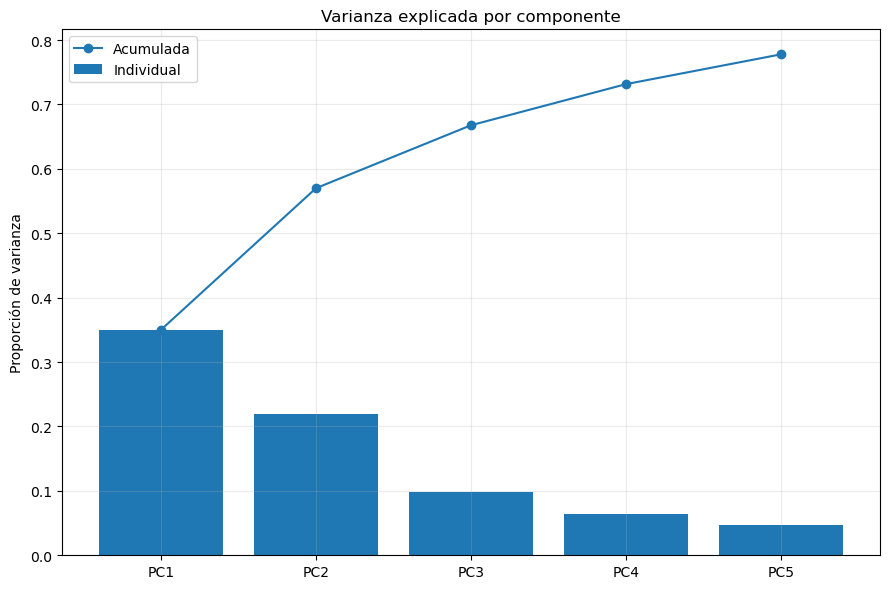

**Figura guardada:** `/home/cdo/Downloads/CEV_db/outputs_analisis_cev_jupyter/pca_pc1_pc2_demanda_calef.png`

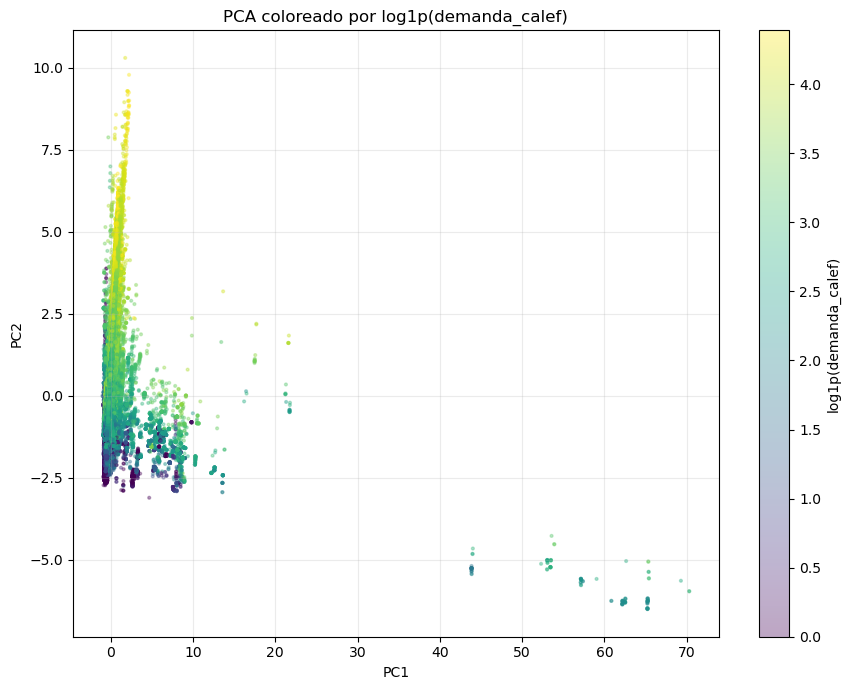

**Figura guardada:** `/home/cdo/Downloads/CEV_db/outputs_analisis_cev_jupyter/pca_loadings_demanda_calef.png`

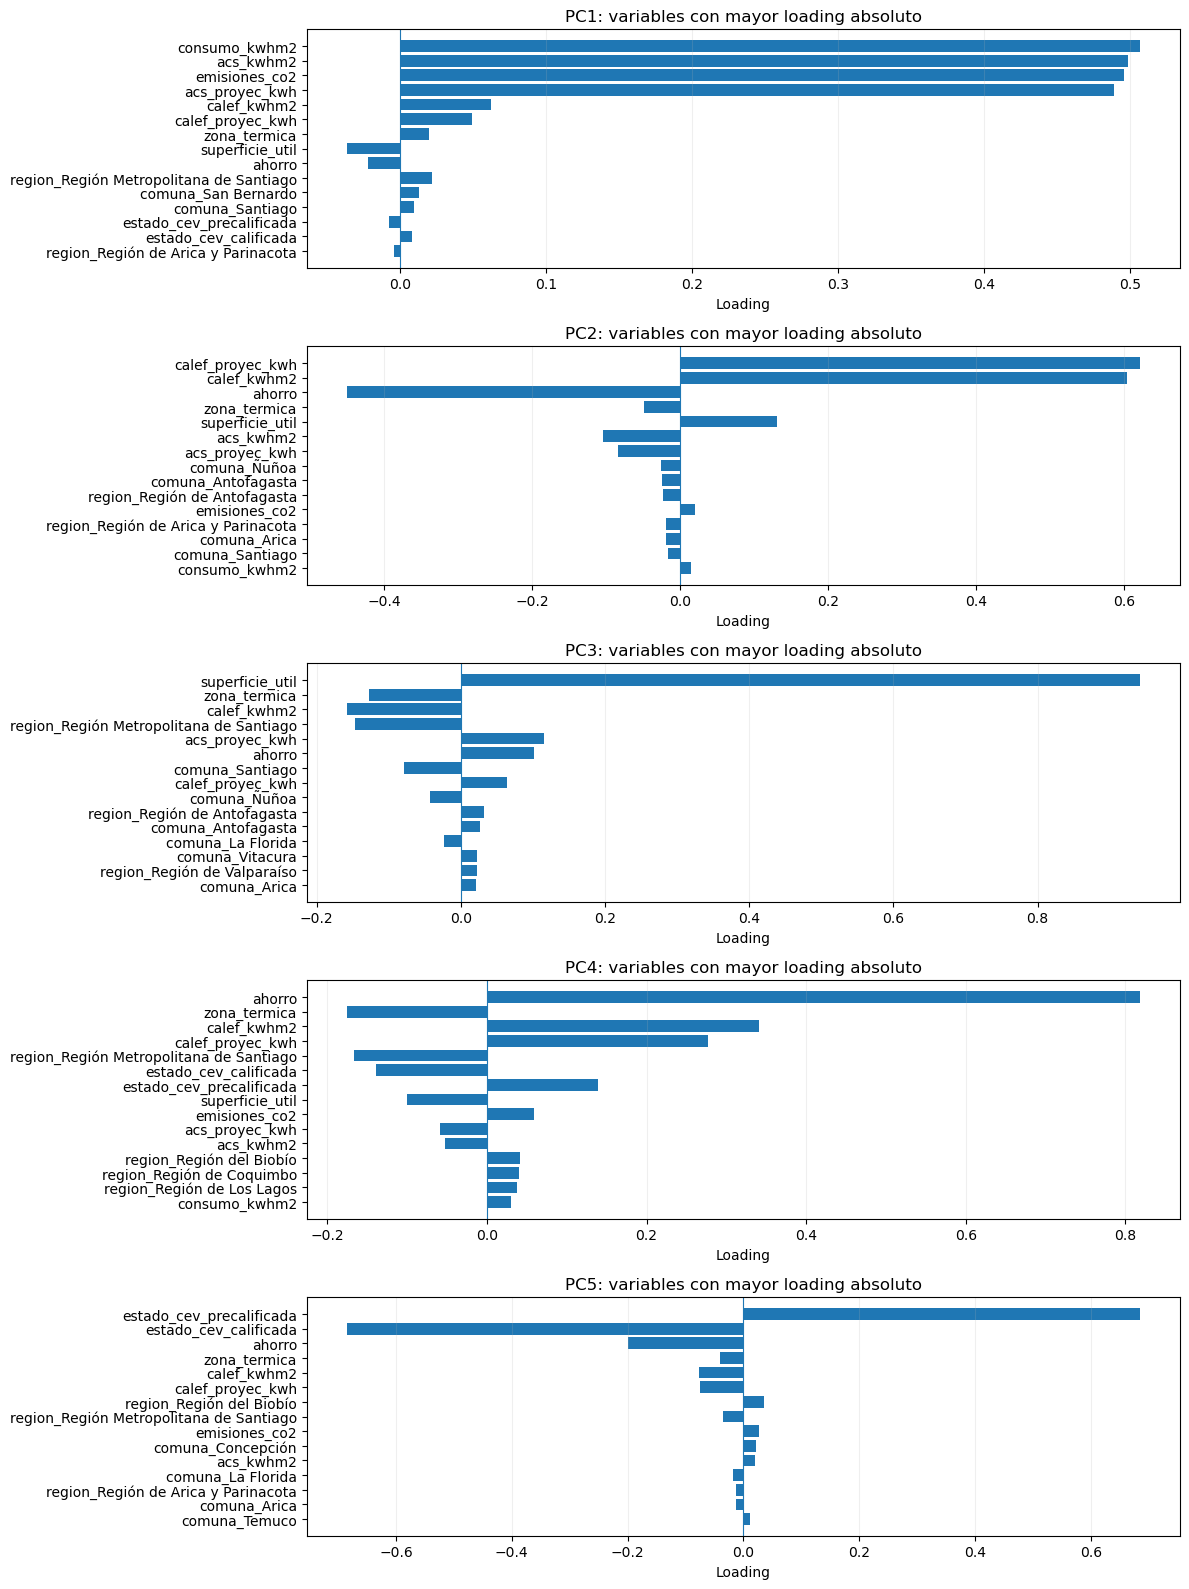

---

✓ PCA estratificado completado. Resultados almacenados en `resultados_por_tipo`.

In [28]:
# ============================================================
# BLOQUE 13: Ejecutar PCA estratificado por tipo de inmueble
# ============================================================

display(Markdown("# PCA Estratificado por Tipo de Inmueble"))
display(Markdown("Análisis separado para cada categoría: casa_aislada, casa_pareada, depto"))

resultados_por_tipo = pca_por_tipo_inmueble(
    data=df,
    target_column="demanda_calef",
    sample_n=None,
    n_components=5,
    remove_outliers=True,
    outlier_quantiles=(0.01, 0.99),
    top_loadings_n=15,
)

display(Markdown("---"))
display(Markdown("✓ PCA estratificado completado. Resultados almacenados en `resultados_por_tipo`."))